### Notebook for ML classification of Healthy/Acne Lesional/Acne Non-Lesional labels using V1-V3, V4, and metabolomics.
### Feature Comparison between V1-V3 and V4 primers for ML classification of skin class. 
### Compositional Tensor Factorization for longitudinal samples. 

In [1]:
import qiime2 as q2
from qiime2 import Artifact
from qiime2 import Metadata
import pandas as pd
import matplotlib.pyplot as plt
import os
from qiime2.plugins.gemelli.actions import ctf, rpca
from qiime2.plugins.emperor.visualizers import biplot, plot
from qiime2.plugins.feature_table.methods import filter_samples
from gemelli.preprocessing import matrix_rclr
from skbio.stats.composition import clr
from biom import load_table
%matplotlib inline

In [2]:
v3_table_original = Artifact.load('../Data/16S/Tables/174950_rarefied_table.qza').view(pd.DataFrame)
v4_table_original = Artifact.load('../Data/16S/Tables/174951_rarefied_table.qza').view(pd.DataFrame)
metabolomics_table = load_table('../Data/metabolomics/Run3_10252024/metabolomics_method2.biom').to_dataframe().T

metadata = pd.read_csv('../Metadata/metadata_Tyler_reordered.csv', index_col=0)
taxonomy = pd.read_csv('../Metadata/174116_taxonomy.tsv', sep='\t', index_col=0)

In [3]:
# Create H, AL, ANL labels based on cohort and category
metadata['label'] = metadata.apply(lambda x: 'H' if x['cohort'] == 'control' else ('AL' if x['cohort'] == 'acne' and x['category'] == 'acne' else ('ANL' if x['cohort'] == 'acne' and x['category'] == 'clear_zone' else None)), axis=1)
metadata['subject_c_zone'] = metadata.subject_randomization_id.astype(str) + '_' + metadata.c_zone.astype(str)

In [4]:
# Function to transform index by removing first two parts
def transform_index(idx):
    parts = idx.split('.')
    return '.'.join(parts[2:])

# Transform indices for metadata
metadata.index = metadata.index.map(transform_index)
# Drop duplicates in metadata (keeping first occurrence)
metadata = metadata.loc[~metadata.index.duplicated(keep='first')]
metadata.to_csv('../Metadata/metadata_processed.tsv', sep='\t', index=True)

# Transform indices for v3_table
v3_table_original.index = v3_table_original.index.map(transform_index)
# Drop duplicates in v3_table
v3_table_original = v3_table_original.loc[~v3_table_original.index.duplicated(keep='first')]

# Transform indices for v4_table
v4_table_original.index = v4_table_original.index.map(transform_index)
# Drop duplicates in v4_table
v4_table_original = v4_table_original.loc[~v4_table_original.index.duplicated(keep='first')]

# Verify the changes (optional)
print(f"Modified metadata shape: {metadata.shape}")
print(f"Modified v3_table shape: {v3_table_original.shape}")
print(f"Modified v4_table shape: {v4_table_original.shape}")

# Create a shared index between all tables
shared_samples = set(metadata.index).intersection(
    set(v3_table_original.index), 
    set(v4_table_original.index), 
    # set(metabolomics_table.index)
)
print(f"\nNumber of samples common to all tables: {len(shared_samples)}")

# Filter all tables to only include samples present in all datasets
metadata = metadata.loc[list(shared_samples)]
v3_table = v3_table_original.loc[list(shared_samples)]
v4_table = v4_table_original.loc[list(shared_samples)]
metabolomics_table = metabolomics_table.loc[metabolomics_table.index.isin(v4_table.index)]#metabolomics_table.loc[list(shared_samples)]

# Verify the filtered tables
print("\nAfter filtering to shared samples:")
print(f"Metadata shape: {metadata.shape}")
print(f"V3 table shape: {v3_table.shape}")
print(f"V4 table shape: {v4_table.shape}")
print(f"Metabolomics table shape: {metabolomics_table.shape}")

Modified metadata shape: (34, 97)
Modified v3_table shape: (250, 158)
Modified v4_table shape: (225, 218)

Number of samples common to all tables: 0

After filtering to shared samples:
Metadata shape: (0, 97)
V3 table shape: (0, 158)
V4 table shape: (0, 218)
Metabolomics table shape: (0, 1142)


In [5]:
# Create a dictionary mapping Feature IDs to their taxonomic classifications
asv_to_taxonomy = taxonomy['Taxon'].to_dict()

# Function to process tables - rename columns and combine those with same taxonomy
def process_table(table):
    # Create a copy to avoid modifying the original
    df = table.copy()
    
    # Dictionary to track columns with the same taxonomy
    taxonomy_groups = {}
    
    # Rename columns using taxonomy information
    for col in df.columns:
        if col in asv_to_taxonomy:
            tax_name = asv_to_taxonomy[col]
            if tax_name in taxonomy_groups:
                taxonomy_groups[tax_name].append(col)
            else:
                taxonomy_groups[tax_name] = [col]
        else:
            # If no taxonomy match found, keep original column name
            taxonomy_groups[f"Unknown_{col[:10]}"] = [col]
    
    # Create a new DataFrame with combined columns
    result_df = pd.DataFrame(index=df.index)
    
    # Combine columns with the same taxonomy by summing their values
    for tax_name, columns in taxonomy_groups.items():
        result_df[tax_name] = df[columns].sum(axis=1)
    
    return result_df

# Process both tables
v3_table_taxonomy = process_table(v3_table)
v4_table_taxonomy = process_table(v4_table)

# Print shapes for verification
print(f"Original v3_table shape: {v3_table.shape}")
print(f"Processed v3_table shape: {v3_table_taxonomy.shape}")
print(f"Original v4_table shape: {v4_table.shape}")
print(f"Processed v4_table shape: {v4_table_taxonomy.shape}")

Original v3_table shape: (0, 158)
Processed v3_table shape: (0, 91)
Original v4_table shape: (0, 218)
Processed v4_table shape: (0, 135)


/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_40131/2173641705.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[tax_name] = df[columns].sum(axis=1)
/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_40131/2173641705.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_df[tax_name] = df[columns].sum(axis=1)
/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_40131/2173641705.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

### Random Forest Classification AUC-ROC for H/AL/ANL for each data type ( on the ASV level for 16S)

In [6]:
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import roc_curve, auc, RocCurveDisplay
# from sklearn.model_selection import GroupKFold
# from sklearn.preprocessing import label_binarize
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# from scipy import interp
# warnings.filterwarnings('ignore')

# # Set overall styling for plots
# plt.style.use('seaborn-whitegrid')
# sns.set_context("paper", font_scale=1.5)
# sns.set_style("ticks")

# # Function to run group-stratified cross-validation with feature importance
# def run_group_cv(X, y, groups, n_splits=5):
#     # Initialize group k-fold
#     gkf = GroupKFold(n_splits=n_splits)
    
#     # Initialize arrays to store results
#     cv_results = []
#     feature_importances = pd.DataFrame(index=X.columns)
    
#     # Run cross-validation
#     for i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
#         X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#         y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
#         # Handle cases where train set might contain only one class
#         if len(np.unique(y_train)) < 2:
#             continue
            
#         # Train classifier
#         clf = RandomForestClassifier(n_estimators=1000, random_state=42)
#         clf.fit(X_train, y_train)
        
#         # Predict probabilities
#         probas = clf.predict_proba(X_test)
        
#         # Store feature importance for this fold
#         feature_importances[f'fold_{i}'] = clf.feature_importances_
        
#         # Store results
#         fpr, tpr, _ = roc_curve(y_test, probas[:, 1])
#         roc_auc = auc(fpr, tpr)
#         cv_results.append({
#             'y_true': y_test,
#             'y_proba': probas[:, 1],
#             'fpr': fpr,
#             'tpr': tpr,
#             'auc': roc_auc
#         })
    
#     # Calculate mean feature importance across folds
#     feature_importances['mean_importance'] = feature_importances.mean(axis=1)
#     feature_importances['std_importance'] = feature_importances.std(axis=1)
#     feature_importances = feature_importances.sort_values('mean_importance', ascending=False)
    
#     return cv_results, feature_importances

# # Function to compute and plot ROC curves with error bars
# def plot_roc_curves_with_errors(tables_dict, metadata, pair_comparisons, n_splits=5):
#     num_tables = len(tables_dict)
#     fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
#     # Dictionary to store feature importances
#     all_feature_importances = {}
    
#     # For each pairwise comparison
#     for i, (label1, label2) in enumerate(pair_comparisons):
#         ax = axs[i]
        
#         # Plot title
#         ax.set_title(f'{label1} vs {label2}', fontsize=16)
#         comparison_key = f'{label1}_vs_{label2}'
#         all_feature_importances[comparison_key] = {}
        
#         # For each data table
#         for table_name, table in tables_dict.items():
#             # Get samples with either label1 or label2
#             meta_subset = metadata[metadata['label'].isin([label1, label2])]
            
#             # Get data table samples that match the metadata subset
#             common_samples = table.index.intersection(meta_subset.index)
#             X = table.loc[common_samples]
#             meta_filtered = meta_subset.loc[common_samples]
            
#             # Skip if insufficient samples
#             if len(common_samples) < 10:
#                 print(f"Skipping {table_name} for {label1} vs {label2}: insufficient samples ({len(common_samples)})")
#                 continue
                
#             # Create binary labels (0 for label1, 1 for label2)
#             y = meta_filtered['label'].map({label1: 0, label2: 1})
            
#             # Get subject IDs for grouping
#             groups = meta_filtered['host_subject_id']
            
#             # Run CV
#             cv_results, feature_imp = run_group_cv(X, y, groups, n_splits=n_splits)
            
#             # Store feature importance
#             all_feature_importances[comparison_key][table_name] = feature_imp
            
#             # Skip if not enough results
#             if len(cv_results) < 2:
#                 print(f"Skipping {table_name} for {label1} vs {label2}: CV returned insufficient results")
#                 continue
            
#             # Interpolate all ROC curves to a common set of FPR points
#             mean_fpr = np.linspace(0, 1, 100)
#             tprs = []
#             aucs = []
            
#             for result in cv_results:
#                 tprs.append(interp(mean_fpr, result['fpr'], result['tpr']))
#                 tprs[-1][0] = 0.0
#                 aucs.append(result['auc'])
            
#             # Calculate mean and std of TPR
#             mean_tpr = np.mean(tprs, axis=0)
#             mean_tpr[-1] = 1.0
#             mean_auc = np.mean(aucs)
#             std_auc = np.std(aucs)
#             std_tpr = np.std(tprs, axis=0)
            
#             # Calculate upper and lower bounds for shaded region
#             tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
#             tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            
#             # Plot mean ROC curve
#             ax.plot(mean_fpr, mean_tpr, lw=2, 
#                    label=f'{table_name} (AUC = {mean_auc:.2f} ± {std_auc:.2f})')
            
#             # Plot shaded region for error bars
#             ax.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.3)
        
#         # Add diagonal line
#         ax.plot([0, 1], [0, 1], 'k--', lw=1)
        
#         # Customize plot
#         ax.set_xlabel('False Positive Rate', fontsize=14)
#         if i == 0:
#             ax.set_ylabel('True Positive Rate', fontsize=14)
#         ax.set_xlim([0.0, 1.0])
#         ax.set_ylim([0.0, 1.05])
#         ax.tick_params(axis='both', which='major', labelsize=12)
#         ax.grid(True, linestyle='--', alpha=0.7)
        
#         # Add legend for each subplot
#         ax.legend(loc='lower right', fontsize=10)
    
#     # Adjust layout
#     plt.tight_layout()
    
#     return fig, all_feature_importances

# # Create a dictionary of tables
# tables = {
#     'V1-V3': v3_table_taxonomy,
#     'V4': v4_table_taxonomy,
#     'Metabolomics': metabolomics_table
# }

# # Define pairwise comparisons
# comparisons = [('H', 'AL'), ('H', 'ANL'), ('AL', 'ANL')]

# # Set number of CV splits
# n_cv_splits = 5

# # Run analysis and plot
# fig, feature_importances = plot_roc_curves_with_errors(tables, metadata, comparisons, n_splits=n_cv_splits)

# # Save figure if desired
# # fig.savefig('roc_curves_comparison.png', dpi=300, bbox_inches='tight')

# plt.show()

# # Display the top 10 most important features for each comparison and data type
# for comparison, data_types in feature_importances.items():
#     print(f"\n{'='*50}")
#     print(f"Top 10 important features for {comparison}:")
#     print(f"{'='*50}")
    
#     for data_type, features_df in data_types.items():
#         print(f"\n{data_type}:")
#         print("-" * 40)
#         top_features = features_df.sort_values('mean_importance', ascending=False).head(10)
#         print(top_features[['mean_importance', 'std_importance']])

# # Return feature importance dataframes for downstream analysis
# feature_importances

Skipping V1-V3 for H vs AL: insufficient samples (0)
Skipping V4 for H vs AL: insufficient samples (0)
Skipping Metabolomics for H vs AL: insufficient samples (0)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Skipping V1-V3 for H vs ANL: insufficient samples (0)
Skipping V4 for H vs ANL: insufficient samples (0)
Skipping Metabolomics for H vs ANL: insufficient samples (0)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Skipping V1-V3 for AL vs ANL: insufficient samples (0)
Skipping V4 for AL vs ANL: insufficient samples (0)
Skipping Metabolomics for AL vs ANL: insufficient samples (0)

Pairwise Performance Comparison of Methods
Empty DataFrame
Columns: []
Index: []

Top 10 important features for H_vs_AL:

Top 10 important features for H_vs_ANL:

Top 10 important features for AL_vs_ANL:


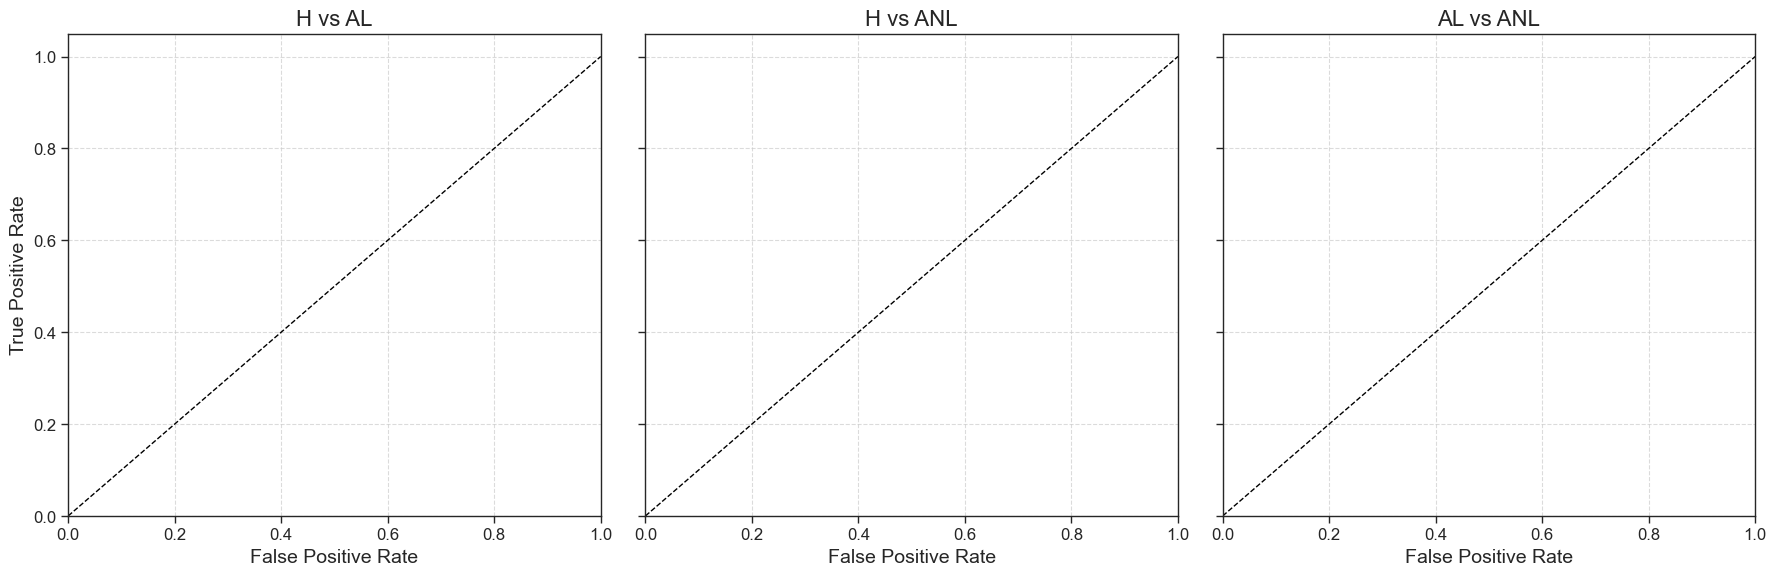

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import interp
from scipy.stats import wilcoxon, ttest_rel
import pandas as pd
from itertools import combinations
warnings.filterwarnings('ignore')

# Set overall styling for plots
plt.style.use('seaborn-whitegrid')
sns.set_context("paper", font_scale=1.5)
sns.set_style("ticks")

# Custom function for group-stratified k-fold
def group_stratified_kfold(X, y, groups, n_splits=5, random_state=42):
    """
    Custom implementation of cross-validation that respects both groups and stratification
    
    Parameters:
    -----------
    X : DataFrame
        Feature matrix
    y : Series
        Target labels
    groups : Series
        Group labels for samples (e.g., host_subject_id)
    n_splits : int
        Number of folds
    random_state : int
        Random seed
    
    Returns:
    --------
    list of tuples
        Each tuple contains (train_indices, test_indices)
    """
    # Get unique groups
    unique_groups = np.unique(groups)
    np.random.seed(random_state)
    np.random.shuffle(unique_groups)
    
    # Create label distribution per group
    group_label_dist = {}
    for group in unique_groups:
        group_mask = groups == group
        group_y = y[group_mask]
        group_label_dist[group] = {label: np.sum(group_y == label) for label in np.unique(y)}
    
    # Initialize folds with empty lists
    folds = [[] for _ in range(n_splits)]
    
    # Track current distribution of labels in each fold
    fold_label_dist = [{label: 0 for label in np.unique(y)} for _ in range(n_splits)]
    
    # Sort groups by size (number of samples) in descending order to place larger groups first
    sorted_groups = sorted(unique_groups, key=lambda g: sum(groups == g), reverse=True)
    
    # Assign groups to folds
    for group in sorted_groups:
        # Calculate which fold would benefit most from this group
        # by minimizing the imbalance across all labels
        best_fold = 0
        min_imbalance = float('inf')
        
        group_size = sum(groups == group)
        
        for fold_idx in range(n_splits):
            # Calculate current imbalance if we add this group
            temp_fold_dist = fold_label_dist[fold_idx].copy()
            for label, count in group_label_dist[group].items():
                temp_fold_dist[label] += count
            
            # Calculate imbalance as variance of label proportions
            fold_size = sum(temp_fold_dist.values())
            if fold_size == 0:
                proportions = [0] * len(temp_fold_dist)
            else:
                proportions = [count / fold_size for count in temp_fold_dist.values()]
            
            imbalance = np.var(proportions) + fold_size / (sum(groups.shape) / n_splits)
            
            if imbalance < min_imbalance:
                min_imbalance = imbalance
                best_fold = fold_idx
        
        # Assign group to best fold
        folds[best_fold].extend(np.where(groups == group)[0])
        # Update fold distribution
        for label, count in group_label_dist[group].items():
            fold_label_dist[best_fold][label] += count
    
    # Create train/test indices
    train_test_indices = []
    for i in range(n_splits):
        test_idx = np.array(folds[i])
        train_idx = np.concatenate([folds[j] for j in range(n_splits) if j != i])
        train_test_indices.append((train_idx, test_idx))
    
    return train_test_indices

# Modified function to run group-stratified cross-validation with feature importance
def run_group_stratified_cv(X, y, groups, n_splits=5):
    # Get group-stratified folds
    folds = group_stratified_kfold(X, y, groups, n_splits=n_splits)
    
    # Initialize arrays to store results
    cv_results = []
    feature_importances = pd.DataFrame(index=X.columns)
    fold_aucs = []
    
    # Run cross-validation
    for i, (train_idx, test_idx) in enumerate(folds):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Handle cases where train set might contain only one class
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Skipping fold {i+1} due to insufficient class representation")
            continue
            
        # Train classifier
        clf = RandomForestClassifier(n_estimators=1000, random_state=42)
        clf.fit(X_train, y_train)
        
        # Predict probabilities
        probas = clf.predict_proba(X_test)
        
        # Store feature importance for this fold
        feature_importances[f'fold_{i}'] = clf.feature_importances_
        
        # Store results
        fpr, tpr, _ = roc_curve(y_test, probas[:, 1])
        roc_auc = auc(fpr, tpr)
        fold_aucs.append(roc_auc)
        
        cv_results.append({
            'y_true': y_test,
            'y_proba': probas[:, 1],
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
            'fold': i
        })
    
    # Calculate mean feature importance across folds
    feature_importances['mean_importance'] = feature_importances.mean(axis=1)
    feature_importances['std_importance'] = feature_importances.std(axis=1)
    feature_importances = feature_importances.sort_values('mean_importance', ascending=False)
    
    return cv_results, feature_importances, fold_aucs

# Function to compute and plot ROC curves with error bars plus perform pairwise comparisons
def plot_roc_curves_with_comparisons(tables_dict, metadata, pair_comparisons, n_splits=5):
    num_tables = len(tables_dict)
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
    # Dictionary to store feature importances and AUCs for each method
    all_feature_importances = {}
    all_fold_aucs = {}
    
    # For each pairwise comparison
    for i, (label1, label2) in enumerate(pair_comparisons):
        ax = axs[i]
        
        # Plot title
        ax.set_title(f'{label1} vs {label2}', fontsize=16)
        comparison_key = f'{label1}_vs_{label2}'
        all_feature_importances[comparison_key] = {}
        all_fold_aucs[comparison_key] = {}
        
        # For each data table
        for table_name, table in tables_dict.items():
            # Get samples with either label1 or label2
            meta_subset = metadata[metadata['label'].isin([label1, label2])]
            
            # Get data table samples that match the metadata subset
            common_samples = table.index.intersection(meta_subset.index)
            X = table.loc[common_samples]
            meta_filtered = meta_subset.loc[common_samples]
            
            # Skip if insufficient samples
            if len(common_samples) < 10:
                print(f"Skipping {table_name} for {label1} vs {label2}: insufficient samples ({len(common_samples)})")
                continue
                
            # Create binary labels (0 for label1, 1 for label2)
            y = meta_filtered['label'].map({label1: 0, label2: 1})
            
            # Get subject IDs for grouping
            groups = meta_filtered['host_subject_id']
            
            # Run CV with group stratification
            cv_results, feature_imp, fold_aucs = run_group_stratified_cv(X, y, groups, n_splits=n_splits)
            
            # Store results
            all_feature_importances[comparison_key][table_name] = feature_imp
            all_fold_aucs[comparison_key][table_name] = fold_aucs
            
            # Skip if not enough results
            if len(cv_results) < 2:
                print(f"Skipping {table_name} for {label1} vs {label2}: CV returned insufficient results")
                continue
            
            # Interpolate all ROC curves to a common set of FPR points
            mean_fpr = np.linspace(0, 1, 100)
            tprs = []
            aucs = []
            
            for result in cv_results:
                tprs.append(interp(mean_fpr, result['fpr'], result['tpr']))
                tprs[-1][0] = 0.0
                aucs.append(result['auc'])
            
            # Calculate mean and std of TPR
            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            std_tpr = np.std(tprs, axis=0)
            
            # Calculate upper and lower bounds for shaded region
            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            
            # Plot mean ROC curve
            ax.plot(mean_fpr, mean_tpr, lw=2, 
                   label=f'{table_name} (AUC = {mean_auc:.2f} ± {std_auc:.2f})')
            
            # Plot shaded region for error bars
            ax.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.3)
        
        # Add diagonal line
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        
        # Customize plot
        ax.set_xlabel('False Positive Rate', fontsize=14)
        if i == 0:
            ax.set_ylabel('True Positive Rate', fontsize=14)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Add legend for each subplot
        ax.legend(loc='lower right', fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    
    # Perform pairwise statistical tests on fold AUCs
    pairwise_comparisons = compute_pairwise_comparisons(all_fold_aucs)
    
    return fig, all_feature_importances, pairwise_comparisons

# Function to perform pairwise statistical tests
def compute_pairwise_comparisons(fold_aucs_dict):
    """
    Perform pairwise statistical tests between methods for each task
    
    Parameters:
    -----------
    fold_aucs_dict : dict
        Dictionary with fold-wise AUC values for each method
    
    Returns:
    --------
    DataFrame
        Table with pairwise comparisons and p-values
    """
    results = []
    
    for task, methods_dict in fold_aucs_dict.items():
        # Get list of methods that have AUC values
        methods = list(methods_dict.keys())
        
        # Perform pairwise comparisons
        for method1, method2 in combinations(methods, 2):
            # Get AUC values for both methods
            aucs1 = methods_dict[method1]
            aucs2 = methods_dict[method2]
            
            # Ensure equal length (use only common folds)
            min_len = min(len(aucs1), len(aucs2))
            if min_len < 2:
                continue
                
            aucs1 = aucs1[:min_len]
            aucs2 = aucs2[:min_len]
            
            # Calculate mean AUCs
            mean_auc1 = np.mean(aucs1)
            mean_auc2 = np.mean(aucs2)
            diff_auc = mean_auc1 - mean_auc2
            
            # Perform statistical tests
            # Wilcoxon signed-rank test (non-parametric)
            try:
                _, p_wilcoxon = wilcoxon(aucs1, aucs2)
            except:
                p_wilcoxon = np.nan
                
            # Paired t-test (parametric)
            _, p_ttest = ttest_rel(aucs1, aucs2)
            
            # Store results
            results.append({
                'Task': task,
                'Method 1': method1,
                'Method 2': method2,
                'Mean AUC 1': mean_auc1,
                'Mean AUC 2': mean_auc2,
                'AUC Difference': diff_auc,
                'p-value (Wilcoxon)': p_wilcoxon,
                'p-value (t-test)': p_ttest,
                'Significant (p<0.05)': (p_wilcoxon < 0.05) if not np.isnan(p_wilcoxon) else (p_ttest < 0.05)
            })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

# Create a dictionary of tables
tables = {
    'V1-V3': v3_table_taxonomy,
    'V4': v4_table_taxonomy,
    'Metabolomics': metabolomics_table
}

# Define pairwise comparisons
comparisons = [('H', 'AL'), ('H', 'ANL'), ('AL', 'ANL')]

# Set number of CV splits
n_cv_splits = 3

# Run analysis and plot
fig, feature_importances, pairwise_stats = plot_roc_curves_with_comparisons(tables, metadata, comparisons, n_splits=n_cv_splits)

# Display pairwise performance comparison table
print("\n" + "="*80)
print("Pairwise Performance Comparison of Methods")
print("="*80)
print(pairwise_stats.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Display the top 10 most important features for each comparison and data type
for comparison, data_types in feature_importances.items():
    print(f"\n{'='*50}")
    print(f"Top 10 important features for {comparison}:")
    print(f"{'='*50}")
    
    for data_type, features_df in data_types.items():
        print(f"\n{data_type}:")
        print("-" * 40)
        top_features = features_df.sort_values('mean_importance', ascending=False).head(10)
        print(top_features[['mean_importance', 'std_importance']])

plt.show()

### Map features to taxonomy for 16S, and then compare between primer sets. 

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

def compare_feature_importances(feature_imp_dict, task, top_n=20):
    """
    Creates improved comparison visualizations between V1-V3 and V4 feature importances
    using ranks for correlation analysis
    
    Parameters:
    -----------
    feature_imp_dict : dict
        Dictionary containing feature importance results
    task : str
        Classification task (e.g., 'H_vs_AL')
    top_n : int
        Number of top features to show in heatmap
    """
    # Format task name for display
    display_task = task.replace('_', ' ')
    
    # Extract feature importances for V1-V3 and V4
    v1v3_imp = feature_imp_dict[task]['V1-V3']
    v4_imp = feature_imp_dict[task]['V4']
    
    # Find overlapping features first
    common_features = set(v1v3_imp.index).intersection(set(v4_imp.index))
    print(f"Number of overlapping features for {display_task}: {len(common_features)}")
    
    # Filter for only overlapping features
    v1v3_filtered = v1v3_imp.loc[v1v3_imp.index.isin(common_features)]
    v4_filtered = v4_imp.loc[v4_imp.index.isin(common_features)]
    
    # Create DataFrames with feature importance values for overlapping features
    v1v3_df = pd.DataFrame({
        'feature': v1v3_filtered.index,
        'importance': v1v3_filtered['mean_importance']
    }).sort_values('importance', ascending=False)
    
    v4_df = pd.DataFrame({
        'feature': v4_filtered.index,
        'importance': v4_filtered['mean_importance']
    }).sort_values('importance', ascending=False)
    
    # Add rank information
    v1v3_df['rank'] = range(1, len(v1v3_df) + 1)
    v4_df['rank'] = range(1, len(v4_df) + 1)
    
    # Merge data for comparison
    merged_df = pd.merge(
        v1v3_df, v4_df,
        on='feature',
        suffixes=('_v1v3', '_v4')
    )
    
    # Calculate correlations based on ranks (not raw importance)
    pearson_r, p_pearson = pearsonr(merged_df['rank_v1v3'], merged_df['rank_v4'])
    spearman_r, p_spearman = spearmanr(merged_df['rank_v1v3'], merged_df['rank_v4'])
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
    fig.suptitle(f"Feature Importance Comparison for {display_task}", fontsize=18, y=0.98)
    
    # 1. Regression plot using ranks
    sns.regplot(
        x='rank_v1v3', 
        y='rank_v4',
        data=merged_df,
        scatter_kws={'alpha': 0.7, 's': 70, 'color': 'navy'},
        line_kws={'color': 'crimson', 'lw': 2.5},
        ax=ax1
    )
    
    # Add correlation text - moved down and away from edge
    ax1.text(
        0.05, 0.80,
        f"Pearson r: {pearson_r:.3f} (p={p_pearson:.4f})\n"
        f"Spearman ρ: {spearman_r:.3f} (p={p_spearman:.4f})",
        transform=ax1.transAxes,
        fontsize=13,
        bbox=dict(facecolor='white', alpha=0.85, boxstyle='round,pad=0.6', edgecolor='lightgray')
    )
    
    ax1.set_title("Correlation of Feature Importance Ranks", fontsize=16)
    ax1.set_xlabel("V1-V3 Feature Rank", fontsize=14)
    ax1.set_ylabel("V4 Feature Rank", fontsize=14)
    
    # Make axes start from origin
    xlim = ax1.get_xlim()
    ylim = ax1.get_ylim()
    min_val = min(xlim[0], ylim[0])
    max_val = max(xlim[1], ylim[1])
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    
    # Add grid lines
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Heatmap of top feature ranks
    # Calculate average rank for selecting top features
    merged_df['avg_rank'] = (merged_df['rank_v1v3'] + merged_df['rank_v4']) / 2
    top_features = merged_df.sort_values('avg_rank').head(top_n)
    
    # Create rank comparison dataframe for heatmap
    heatmap_data = pd.DataFrame({
        'V1-V3 Rank': top_features['rank_v1v3'].values,
        'V4 Rank': top_features['rank_v4'].values
    }, index=top_features['feature'])
    
    # Simplify taxonomy names for better display
    simplified_names = []
    for feature in heatmap_data.index:
        # Extract most specific taxonomic level
        parts = feature.split('; ')
        if len(parts) > 1:
            # Get the most specific levels with actual taxonomic information
            filtered_parts = [p for p in parts if any(p.startswith(prefix) for prefix in 
                                                    ['p__', 'c__', 'o__', 'f__', 'g__', 's__'])]
            if len(filtered_parts) >= 2:
                simplified = '; '.join(filtered_parts[-2:])
            elif len(filtered_parts) == 1:
                simplified = filtered_parts[0]
            else:
                simplified = parts[-1]
            simplified_names.append(simplified)
        else:
            simplified_names.append(feature)
    
    heatmap_data.index = simplified_names
    
    # Plot heatmap with improved formatting
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.0f',
        cmap='viridis_r',  # Changed colormap
        linewidths=0.8,
        ax=ax2,
        cbar_kws={'label': 'Rank (lower is better)', 'shrink': 0.8}
    )
    
    ax2.set_title(f"Top {top_n} Features by Average Rank", fontsize=16)
    ax2.tick_params(axis='y', rotation=0)  # Improved y-axis tick readability
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for the suptitle
    plt.show()
    
    return merged_df

# Run comparisons for all three classification tasks
tasks = ['H_vs_AL', 'H_vs_ANL', 'AL_vs_ANL']
comparison_results = {}

for task in tasks:
    print(f"\n{'='*60}\nAnalyzing {task.replace('_', ' ')} classification\n{'='*60}")
    if task in feature_importances and 'V1-V3' in feature_importances[task] and 'V4' in feature_importances[task]:
        comparison_results[task] = compare_feature_importances(feature_importances, task)
    else:
        print(f"Missing data for task {task}")


Analyzing H vs AL classification
Missing data for task H_vs_AL

Analyzing H vs ANL classification
Missing data for task H_vs_ANL

Analyzing AL vs ANL classification
Missing data for task AL_vs_ANL


### CTF for longitudinal data.

In [9]:
from matplotlib import transforms
from qiime2.plugins.gemelli.actions import phylogenetic_ctf_with_taxonomy
from skbio import OrdinationResults

In [10]:


def run_ctf(table, q2_metadata, taxonomy, output_path):

    # Import necessary libraries
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from matplotlib.patches import Ellipse
    from scipy.stats import gaussian_kde
    import matplotlib.patheffects as pe
    
    # Set publication-quality styling
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in vector graphics
    sns.set_style("white")
    sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 2.5})
    
    # Professional color palette (colorblind-friendly)
    colors = {
        'AL': '#E64B35',     # Red shade
        'ANL': '#F39B7F',    # Orange shade
        'H': '#4DBBD5'       # Blue shade
    }
    
    # Run RPCA as before
    rpca_biplot, rpca_distance = rpca(table)
    rpca_biplot_emperor = biplot(rpca_biplot, q2_metadata)
    
    # Create the directory if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    # Save RPCA visualization
    rpca_biplot_emperor.visualization.save(os.path.join(output_path, 'RPCA-biplot.qzv'))
    
    # Run CTF with appropriate error handling
    try:
        ctf_results = ctf(table, q2_metadata,
                         'subject_c_zone',
                         'day',
                         feature_metadata=taxonomy)

    except:
        ctf_results = ctf(table, q2_metadata,
                         'subject_c_zone',
                         'day')
    
    # Create subject metadata
    mf = q2_metadata.to_dataframe().reset_index().groupby('subject_c_zone').agg(
        {'cohort':'first', 'class':'first', 'acne_severity':'first', 
         'c_zone':'first', 'category':'first', 'label':'first'})
    mf.index.name = '#SampleID'
    mf.to_csv(os.path.join(output_path, 'subject-metadata.tsv'), sep='\t', index=True)
    
    # Create subject biplot
    try:
        subject_biplot_emperor = biplot(ctf_results.subject_biplot,
                                       sample_metadata=q2.Metadata(mf),
                                       feature_metadata=taxonomy,
                                       ignore_missing_samples=True,
                                       number_of_features=50)
        
        ctf_feature_loadings = ctf_results.subject_biplot.view(OrdinationResults).features.rename({0:'PC1',
                                                                                                        1:"PC2",
                                                                                                        2:"PC3"},
                                                                                                        axis=1)
        ctf_feature_loadings.index.name = 'featureid'
        ctf_feature_loadings.to_csv(os.path.join(output_path, 'ctf_feature_loadings.tsv'), sep='\t', index=True)
        try:
            taxonomy_df = taxonomy.to_dataframe()
            ctf_taxonomy_and_loadings = pd.concat([taxonomy_df, ctf_feature_loadings], axis=1)
            ctf_taxonomy_and_loadings.index.name = 'featureid'
            ctf_taxonomy_and_loadings.to_csv(os.path.join(output_path, 'ctf_taxonomy_and_loadings.tsv'), sep='\t', index=True)
        except Exception as e:
            print("Could not combine taxonomy with feature loadings:", e)

    except:
        # For metabolomics with no taxonomy metadata
        subject_biplot_emperor = biplot(ctf_results.subject_biplot,
                                       sample_metadata=q2.Metadata(mf),
                                       ignore_missing_samples=True,
                                       number_of_features=50)
    
    # Save subject biplot visualization
    subject_biplot_emperor.visualization.save(os.path.join(output_path, 'subject_biplot.qzv'))
    
    # ===== ENHANCED PUBLICATION-QUALITY PLOTTING =====
    
    # Extract CTF data
    df_ctf = ctf_results.subject_biplot.view(q2.metadata.metadata.Metadata).to_dataframe()
    
    # Separate samples by label
    groups = {}
    group_labels = ['AL', 'ANL', 'H']
    for label in group_labels:
        groups[label] = df_ctf[df_ctf.index.isin(mf.loc[mf.label==label].index)]
    
    # Create a multi-panel figure
    fig = plt.figure(figsize=(14, 10), dpi=300)
    
    # Panel 1: Main CTF ordination plot with ellipses
    ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=2, rowspan=2)
    
    # Function to plot confidence ellipses
    def plot_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
        """
        Create a plot of the covariance confidence ellipse of x and y.
        
        Parameters
        ----------
        x, y : array-like
            Input data.
        ax : matplotlib.axes.Axes
            The axes object to draw the ellipse into.
        n_std : float
            The number of standard deviations to determine the ellipse's radiuses.
        **kwargs
            Forwarded to `~matplotlib.patches.Ellipse`
        
        Returns
        -------
        matplotlib.patches.Ellipse
        """
        if x.size != y.size:
            raise ValueError("x and y must be the same size")
            
        cov = np.cov(x, y)
        pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
        
        # Using a special case to obtain the eigenvalues of this
        # two-dimensional dataset.
        ell_radius_x = np.sqrt(1 + pearson)
        ell_radius_y = np.sqrt(1 - pearson)
        ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                         **kwargs)
        
        # Calculating the standard deviation of x from the square root of
        # the variance and multiplying with the given number of standard deviations.
        scale_x = np.sqrt(cov[0, 0]) * n_std
        mean_x = np.mean(x)
        
        # Calculating the standard deviation of y from the square root of
        # the variance and multiplying with the given number of standard deviations.
        scale_y = np.sqrt(cov[1, 1]) * n_std
        mean_y = np.mean(y)
        
        transf = transforms.Affine2D() \
            .rotate_deg(45) \
            .scale(scale_x, scale_y) \
            .translate(mean_x, mean_y)
            
        ellipse.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse)
    
    # Plot samples with enhanced styling
    for label, data in groups.items():
        if data.empty:
            continue
            
        x = data['Axis 1'].values
        y = data['Axis 2'].values
        
        # Draw scatter points
        ax1.scatter(x, y, c=colors[label], s=80, alpha=0.7, edgecolor='white', 
                   linewidth=0.5, label=label)
        
        # Add confidence ellipses (95% confidence)
        if len(x) >= 3:  # Need at least 3 points for covariance calculation
            plot_confidence_ellipse(x, y, ax1, n_std=1.96, facecolor=colors[label], 
                                  alpha=0.2, edgecolor=colors[label], linewidth=1)
    
    # Customize plot appearance
    ax1.set_xlabel('Axis 1', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Axis 2', fontsize=14, fontweight='bold')
    
    # Determine axis limits with 10% padding
    all_x = np.concatenate([data['Axis 1'].values for data in groups.values() if not data.empty])
    all_y = np.concatenate([data['Axis 2'].values for data in groups.values() if not data.empty])
    x_range = max(all_x) - min(all_x)
    y_range = max(all_y) - min(all_y)
    x_padding = x_range * 0.1
    y_padding = y_range * 0.1
    
    ax1.set_xlim([min(all_x) - x_padding, max(all_x) + x_padding])
    ax1.set_ylim([min(all_y) - y_padding, max(all_y) + y_padding])
    
    # Add grid and spines
    ax1.grid(True, linestyle='--', alpha=0.3)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)
    
    # Add legend with custom styling
    legend = ax1.legend(title="Group", frameon=True, fontsize=12, 
                      title_fontsize=14, loc='best', 
                      framealpha=0.95, edgecolor='gray')
    legend.get_frame().set_linewidth(1.5)
    
    # Add title
    ax1.set_title(f"{output_path.split('_')[0]} Ordination", 
                fontsize=16, fontweight='bold', pad=20)
    
    # Panel 2: Density plot for Axis 1
    ax2 = plt.subplot2grid((2, 3), (0, 2), rowspan=1)
    
    # Create density plots for each group along Axis 1
    for label, data in groups.items():
        if data.empty or len(data) < 3:
            continue
            
        sns.kdeplot(data['Axis 1'], ax=ax2, color=colors[label], 
                   label=label, linewidth=2.5, fill=True, alpha=0.3)
    
    ax2.set_title('Axis 1 Density', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Axis 1', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # Panel 3: Density plot for Axis 2
    ax3 = plt.subplot2grid((2, 3), (1, 2), rowspan=1)
    
    # Create density plots for each group along Axis 2
    for label, data in groups.items():
        if data.empty or len(data) < 3:
            continue
            
        sns.kdeplot(data['Axis 2'], ax=ax3, color=colors[label], 
                   label=label, linewidth=2.5, fill=True, alpha=0.3)
    
    ax3.set_title('Axis 2 Density', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Axis 2', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.3)
    
    # Add dataset statistics as a text box
    stats_text = (
        f"Dataset: {output_path.split('_')[0]}\n"
        f"AL samples: {len(groups['AL']) if 'AL' in groups else 0}\n"
        f"ANL samples: {len(groups['ANL']) if 'ANL' in groups else 0}\n"
        f"H samples: {len(groups['H']) if 'H' in groups else 0}\n"
    )
    
    # Add a text box with statistics
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    # Adjust layout and spacing
    plt.tight_layout()
    
    # Save high-resolution figures in multiple formats
    for fmt in ['png', 'pdf', 'svg']:
        output_file = os.path.join(output_path, f'ctf_plot.{fmt}')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    # Save the original simple plot for backward compatibility
    plt.figure(figsize=(8, 6))
    for label, data in groups.items():
        if not data.empty:
            plt.scatter(data['Axis 1'], data['Axis 2'], c=colors[label], 
                       label=label, s=60, alpha=0.7, edgecolor='white')
    
    plt.title(output_path.split('_')[0])
    plt.xlabel('Axis 1')
    plt.ylabel('Axis 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.savefig(os.path.join(output_path, 'pc_plot.png'), dpi=200)
    
    return ctf_results

def run_phylo_ctf(table, q2_metadata, taxonomy, tree, output_path):

    # Import necessary libraries
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from matplotlib.patches import Ellipse
    from scipy.stats import gaussian_kde
    import matplotlib.patheffects as pe
    
    # Set publication-quality styling
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in vector graphics
    sns.set_style("white")
    sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 2.5})
    
    # Professional color palette (colorblind-friendly)
    colors = {
        'AL': '#E64B35',     # Red shade
        'ANL': '#F39B7F',    # Orange shade
        'H': '#4DBBD5'       # Blue shade
    }
    
    # Run RPCA as before
    rpca_biplot, rpca_distance = rpca(table)
    rpca_biplot_emperor = biplot(rpca_biplot, q2_metadata)
    
    # Create the directory if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    # Save RPCA visualization
    rpca_biplot_emperor.visualization.save(os.path.join(output_path, 'RPCA-biplot.qzv'))
    
    # Run CTF with appropriate error handling
    try:

        ctf_results = phylogenetic_ctf_with_taxonomy(table, tree, taxonomy,
                                             q2_metadata, 'subject_c_zone', 'day',
                                             min_feature_frequency=10)
    except Exception as e:
        print(e)
    
    # Create subject metadata
    mf = q2_metadata.to_dataframe().reset_index().groupby('subject_c_zone').agg(
        {'cohort':'first', 'class':'first', 'acne_severity':'first', 
         'c_zone':'first', 'category':'first', 'label':'first'})
    mf.index.name = '#SampleID'
    mf.to_csv(os.path.join(output_path, 'subject-metadata.tsv'), sep='\t', index=True)
    
    # Create subject biplot
    try:
    
        # combine feature metadata
        phylo_ctf_taxonomy = ctf_results.t2t_taxonomy.view(q2.Metadata).to_dataframe()
        phylo_ctf_feature_loadings = ctf_results.subject_biplot.view(OrdinationResults).features.rename({0:'PC1',
                                                                                                        1:"PC2",
                                                                                                        2:"PC3"},
                                                                                                        axis=1)
        phylo_ctf_taxonomy_and_loadings = pd.concat([phylo_ctf_taxonomy, phylo_ctf_feature_loadings], axis=1)
        phylo_ctf_taxonomy_and_loadings.index.name = 'featureid'
        phylo_ctf_taxonomy_and_loadings.to_csv(os.path.join(output_path, 'phylo_ctf_taxonomy_and_loadings.tsv'), sep='\t', index=True)
        joint_tree_biplot = community_plot(ctf_results.counts_by_node_tree,
                                    ctf_results.subject_table,
                                    q2.Metadata(mf),
                                    pcoa = ctf_results.subject_biplot,
                                    feature_metadata = q2.Metadata(phylo_ctf_taxonomy_and_loadings),
                                    number_of_features=50,
                                    ignore_missing_samples=True,
                                    filter_extra_samples=True,
                                    filter_missing_features=True)
        joint_tree_biplot.visualization.save(os.path.join(output_path, 'joint_tree_biplot.qzv'))

    except Exception as e:
        print(e)

    # ===== ENHANCED PUBLICATION-QUALITY PLOTTING =====
    
    # Extract CTF data
    df_ctf = ctf_results.subject_biplot.view(q2.metadata.metadata.Metadata).to_dataframe()
    
    # Separate samples by label
    groups = {}
    group_labels = ['AL', 'ANL', 'H']
    for label in group_labels:
        groups[label] = df_ctf[df_ctf.index.isin(mf.loc[mf.label==label].index)]
    
    # Create a multi-panel figure
    fig = plt.figure(figsize=(14, 10), dpi=300)
    
    # Panel 1: Main CTF ordination plot with ellipses
    ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=2, rowspan=2)
    
    # Function to plot confidence ellipses
    def plot_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
        """
        Create a plot of the covariance confidence ellipse of x and y.
        
        Parameters
        ----------
        x, y : array-like
            Input data.
        ax : matplotlib.axes.Axes
            The axes object to draw the ellipse into.
        n_std : float
            The number of standard deviations to determine the ellipse's radiuses.
        **kwargs
            Forwarded to `~matplotlib.patches.Ellipse`
        
        Returns
        -------
        matplotlib.patches.Ellipse
        """
        if x.size != y.size:
            raise ValueError("x and y must be the same size")
            
        cov = np.cov(x, y)
        pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
        
        # Using a special case to obtain the eigenvalues of this
        # two-dimensional dataset.
        ell_radius_x = np.sqrt(1 + pearson)
        ell_radius_y = np.sqrt(1 - pearson)
        ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                         **kwargs)
        
        # Calculating the standard deviation of x from the square root of
        # the variance and multiplying with the given number of standard deviations.
        scale_x = np.sqrt(cov[0, 0]) * n_std
        mean_x = np.mean(x)
        
        # Calculating the standard deviation of y from the square root of
        # the variance and multiplying with the given number of standard deviations.
        scale_y = np.sqrt(cov[1, 1]) * n_std
        mean_y = np.mean(y)
        
        transf = transforms.Affine2D() \
            .rotate_deg(45) \
            .scale(scale_x, scale_y) \
            .translate(mean_x, mean_y)
            
        ellipse.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse)
    
    # Plot samples with enhanced styling
    for label, data in groups.items():
        if data.empty:
            continue
            
        x = data['Axis 1'].values
        y = data['Axis 2'].values
        
        # Draw scatter points
        ax1.scatter(x, y, c=colors[label], s=80, alpha=0.7, edgecolor='white', 
                   linewidth=0.5, label=label)
        
        # Add confidence ellipses (95% confidence)
        if len(x) >= 3:  # Need at least 3 points for covariance calculation
            plot_confidence_ellipse(x, y, ax1, n_std=1.96, facecolor=colors[label], 
                                  alpha=0.2, edgecolor=colors[label], linewidth=1)
    
    # Customize plot appearance
    ax1.set_xlabel('Axis 1', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Axis 2', fontsize=14, fontweight='bold')
    
    # Determine axis limits with 10% padding
    all_x = np.concatenate([data['Axis 1'].values for data in groups.values() if not data.empty])
    all_y = np.concatenate([data['Axis 2'].values for data in groups.values() if not data.empty])
    x_range = max(all_x) - min(all_x)
    y_range = max(all_y) - min(all_y)
    x_padding = x_range * 0.1
    y_padding = y_range * 0.1
    
    ax1.set_xlim([min(all_x) - x_padding, max(all_x) + x_padding])
    ax1.set_ylim([min(all_y) - y_padding, max(all_y) + y_padding])
    
    # Add grid and spines
    ax1.grid(True, linestyle='--', alpha=0.3)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)
    
    # Add legend with custom styling
    legend = ax1.legend(title="Group", frameon=True, fontsize=12, 
                      title_fontsize=14, loc='best', 
                      framealpha=0.95, edgecolor='gray')
    legend.get_frame().set_linewidth(1.5)
    
    # Add title
    ax1.set_title(f"{output_path.split('_')[0]} Ordination", 
                fontsize=16, fontweight='bold', pad=20)
    
    # Panel 2: Density plot for Axis 1
    ax2 = plt.subplot2grid((2, 3), (0, 2), rowspan=1)
    
    # Create density plots for each group along Axis 1
    for label, data in groups.items():
        if data.empty or len(data) < 3:
            continue
            
        sns.kdeplot(data['Axis 1'], ax=ax2, color=colors[label], 
                   label=label, linewidth=2.5, fill=True, alpha=0.3)
    
    ax2.set_title('Axis 1 Density', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Axis 1', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # Panel 3: Density plot for Axis 2
    ax3 = plt.subplot2grid((2, 3), (1, 2), rowspan=1)
    
    # Create density plots for each group along Axis 2
    for label, data in groups.items():
        if data.empty or len(data) < 3:
            continue
            
        sns.kdeplot(data['Axis 2'], ax=ax3, color=colors[label], 
                   label=label, linewidth=2.5, fill=True, alpha=0.3)
    
    ax3.set_title('Axis 2 Density', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Axis 2', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.3)
    
    # Add dataset statistics as a text box
    stats_text = (
        f"Dataset: {output_path.split('_')[0]}\n"
        f"AL samples: {len(groups['AL']) if 'AL' in groups else 0}\n"
        f"ANL samples: {len(groups['ANL']) if 'ANL' in groups else 0}\n"
        f"H samples: {len(groups['H']) if 'H' in groups else 0}\n"
    )
    
    # Add a text box with statistics
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    # Adjust layout and spacing
    plt.tight_layout()
    
    # Save high-resolution figures in multiple formats
    for fmt in ['png', 'pdf', 'svg']:
        output_file = os.path.join(output_path, f'ctf_plot.{fmt}')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    # Save the original simple plot for backward compatibility
    plt.figure(figsize=(8, 6))
    for label, data in groups.items():
        if not data.empty:
            plt.scatter(data['Axis 1'], data['Axis 2'], c=colors[label], 
                       label=label, s=60, alpha=0.7, edgecolor='white')
    
    plt.title(output_path.split('_')[0])
    plt.xlabel('Axis 1')
    plt.ylabel('Axis 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.savefig(os.path.join(output_path, 'pc_plot.png'), dpi=200)
    
    return ctf_results

In [11]:


def run_ctf(table, q2_metadata, taxonomy, output_path):

    # Import necessary libraries
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from matplotlib.patches import Ellipse
    from scipy.stats import gaussian_kde
    import matplotlib.patheffects as pe
    
    # Set publication-quality styling
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in vector graphics
    sns.set_style("white")
    sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 2.5})
    
    # Professional color palette (colorblind-friendly)
    colors = {
        'AL': '#E64B35',     # Red shade
        'ANL': '#F39B7F',    # Orange shade
        'H': '#4DBBD5'       # Blue shade
    }
    
    # Run RPCA as before
    rpca_biplot, rpca_distance = rpca(table)
    rpca_biplot_emperor = biplot(rpca_biplot, q2_metadata)
    
    # Create the directory if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    # Save RPCA visualization
    rpca_biplot_emperor.visualization.save(os.path.join(output_path, 'RPCA-biplot.qzv'))
    
    # Run CTF with appropriate error handling
    try:
        ctf_results = ctf(table, q2_metadata,
                         'subject_c_zone',
                         'day',
                         feature_metadata=taxonomy)

    except:
        ctf_results = ctf(table, q2_metadata,
                         'subject_c_zone',
                         'day')
    
    # Create subject metadata
    mf = q2_metadata.to_dataframe().reset_index().groupby('subject_c_zone').agg(
        {'cohort':'first', 'class':'first', 'acne_severity':'first', 
         'c_zone':'first', 'category':'first', 'label':'first'})
    mf.index.name = '#SampleID'
    mf.to_csv(os.path.join(output_path, 'subject-metadata.tsv'), sep='\t', index=True)
    
    # Create subject biplot
    try:
        subject_biplot_emperor = biplot(ctf_results.subject_biplot,
                                       sample_metadata=q2.Metadata(mf),
                                       feature_metadata=taxonomy,
                                       ignore_missing_samples=True,
                                       number_of_features=50)
        
        ctf_feature_loadings = ctf_results.subject_biplot.view(OrdinationResults).features.rename({0:'PC1',
                                                                                                        1:"PC2",
                                                                                                        2:"PC3"},
                                                                                                        axis=1)
        ctf_feature_loadings.index.name = 'featureid'
        ctf_feature_loadings.to_csv(os.path.join(output_path, 'ctf_feature_loadings.tsv'), sep='\t', index=True)

    except:
        # For metabolomics with no taxonomy metadata
        subject_biplot_emperor = biplot(ctf_results.subject_biplot,
                                       sample_metadata=q2.Metadata(mf),
                                       ignore_missing_samples=True,
                                       number_of_features=50)
    
    # Save subject biplot visualization
    subject_biplot_emperor.visualization.save(os.path.join(output_path, 'subject_biplot.qzv'))
    
    # ===== ENHANCED PUBLICATION-QUALITY PLOTTING =====
    
    # Extract CTF data
    df_ctf = ctf_results.subject_biplot.view(q2.metadata.metadata.Metadata).to_dataframe()
    
    # Separate samples by label
    groups = {}
    group_labels = ['AL', 'ANL', 'H']
    for label in group_labels:
        groups[label] = df_ctf[df_ctf.index.isin(mf.loc[mf.label==label].index)]
    
    # Create a multi-panel figure
    fig = plt.figure(figsize=(14, 10), dpi=300)
    
    # Panel 1: Main CTF ordination plot with ellipses
    ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=2, rowspan=2)
    
    # Function to plot confidence ellipses
    def plot_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
        """
        Create a plot of the covariance confidence ellipse of x and y.
        
        Parameters
        ----------
        x, y : array-like
            Input data.
        ax : matplotlib.axes.Axes
            The axes object to draw the ellipse into.
        n_std : float
            The number of standard deviations to determine the ellipse's radiuses.
        **kwargs
            Forwarded to `~matplotlib.patches.Ellipse`
        
        Returns
        -------
        matplotlib.patches.Ellipse
        """
        if x.size != y.size:
            raise ValueError("x and y must be the same size")
            
        cov = np.cov(x, y)
        pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
        
        # Using a special case to obtain the eigenvalues of this
        # two-dimensional dataset.
        ell_radius_x = np.sqrt(1 + pearson)
        ell_radius_y = np.sqrt(1 - pearson)
        ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                         **kwargs)
        
        # Calculating the standard deviation of x from the square root of
        # the variance and multiplying with the given number of standard deviations.
        scale_x = np.sqrt(cov[0, 0]) * n_std
        mean_x = np.mean(x)
        
        # Calculating the standard deviation of y from the square root of
        # the variance and multiplying with the given number of standard deviations.
        scale_y = np.sqrt(cov[1, 1]) * n_std
        mean_y = np.mean(y)
        
        transf = transforms.Affine2D() \
            .rotate_deg(45) \
            .scale(scale_x, scale_y) \
            .translate(mean_x, mean_y)
            
        ellipse.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse)
    
    # Plot samples with enhanced styling
    for label, data in groups.items():
        if data.empty:
            continue
            
        x = data['Axis 1'].values
        y = data['Axis 2'].values
        
        # Draw scatter points
        ax1.scatter(x, y, c=colors[label], s=80, alpha=0.7, edgecolor='white', 
                   linewidth=0.5, label=label)
        
        # Add confidence ellipses (95% confidence)
        if len(x) >= 3:  # Need at least 3 points for covariance calculation
            plot_confidence_ellipse(x, y, ax1, n_std=1.96, facecolor=colors[label], 
                                  alpha=0.2, edgecolor=colors[label], linewidth=1)
    
    # Customize plot appearance
    ax1.set_xlabel('Axis 1', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Axis 2', fontsize=14, fontweight='bold')
    
    # Determine axis limits with 10% padding
    all_x = np.concatenate([data['Axis 1'].values for data in groups.values() if not data.empty])
    all_y = np.concatenate([data['Axis 2'].values for data in groups.values() if not data.empty])
    x_range = max(all_x) - min(all_x)
    y_range = max(all_y) - min(all_y)
    x_padding = x_range * 0.1
    y_padding = y_range * 0.1
    
    ax1.set_xlim([min(all_x) - x_padding, max(all_x) + x_padding])
    ax1.set_ylim([min(all_y) - y_padding, max(all_y) + y_padding])
    
    # Add grid and spines
    ax1.grid(True, linestyle='--', alpha=0.3)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)
    
    # Add legend with custom styling
    legend = ax1.legend(title="Group", frameon=True, fontsize=12, 
                      title_fontsize=14, loc='best', 
                      framealpha=0.95, edgecolor='gray')
    legend.get_frame().set_linewidth(1.5)
    
    # Add title
    ax1.set_title(f"{output_path.split('_')[0]} Ordination", 
                fontsize=16, fontweight='bold', pad=20)
    
    # Panel 2: Density plot for Axis 1
    ax2 = plt.subplot2grid((2, 3), (0, 2), rowspan=1)
    
    # Create density plots for each group along Axis 1
    for label, data in groups.items():
        if data.empty or len(data) < 3:
            continue
            
        sns.kdeplot(data['Axis 1'], ax=ax2, color=colors[label], 
                   label=label, linewidth=2.5, fill=True, alpha=0.3)
    
    ax2.set_title('Axis 1 Density', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Axis 1', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # Panel 3: Density plot for Axis 2
    ax3 = plt.subplot2grid((2, 3), (1, 2), rowspan=1)
    
    # Create density plots for each group along Axis 2
    for label, data in groups.items():
        if data.empty or len(data) < 3:
            continue
            
        sns.kdeplot(data['Axis 2'], ax=ax3, color=colors[label], 
                   label=label, linewidth=2.5, fill=True, alpha=0.3)
    
    ax3.set_title('Axis 2 Density', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Axis 2', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.3)
    
    # Add dataset statistics as a text box
    stats_text = (
        f"Dataset: {output_path.split('_')[0]}\n"
        f"AL samples: {len(groups['AL']) if 'AL' in groups else 0}\n"
        f"ANL samples: {len(groups['ANL']) if 'ANL' in groups else 0}\n"
        f"H samples: {len(groups['H']) if 'H' in groups else 0}\n"
    )
    
    # Add a text box with statistics
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    # Adjust layout and spacing
    plt.tight_layout()
    
    # Save high-resolution figures in multiple formats
    for fmt in ['png', 'pdf', 'svg']:
        output_file = os.path.join(output_path, f'ctf_plot.{fmt}')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    # Save the original simple plot for backward compatibility
    plt.figure(figsize=(8, 6))
    for label, data in groups.items():
        if not data.empty:
            plt.scatter(data['Axis 1'], data['Axis 2'], c=colors[label], 
                       label=label, s=60, alpha=0.7, edgecolor='white')
    
    plt.title(output_path.split('_')[0])
    plt.xlabel('Axis 1')
    plt.ylabel('Axis 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.savefig(os.path.join(output_path, 'pc_plot.png'), dpi=200)
    
    return ctf_results

def run_phylo_ctf(table, q2_metadata, taxonomy, tree, output_path):

    # Import necessary libraries
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from matplotlib.patches import Ellipse
    from scipy.stats import gaussian_kde
    import matplotlib.patheffects as pe
    
    # Set publication-quality styling
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in vector graphics
    sns.set_style("white")
    sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 2.5})
    
    # Professional color palette (colorblind-friendly)
    colors = {
        'AL': '#E64B35',     # Red shade
        'ANL': '#F39B7F',    # Orange shade
        'H': '#4DBBD5'       # Blue shade
    }
    
    # Run RPCA as before
    rpca_biplot, rpca_distance = rpca(table)
    rpca_biplot_emperor = biplot(rpca_biplot, q2_metadata)
    
    # Create the directory if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    # Save RPCA visualization
    rpca_biplot_emperor.visualization.save(os.path.join(output_path, 'RPCA-biplot.qzv'))
    
    # Run CTF with appropriate error handling
    try:

        ctf_results = phylogenetic_ctf_with_taxonomy(table, tree, taxonomy,
                                             q2_metadata, 'subject_c_zone', 'day',
                                             min_feature_frequency=10)
    except Exception as e:
        print(e)
    
    # Create subject metadata
    mf = q2_metadata.to_dataframe().reset_index().groupby('subject_c_zone').agg(
        {'cohort':'first', 'class':'first', 'acne_severity':'first', 
         'c_zone':'first', 'category':'first', 'label':'first'})
    mf.index.name = '#SampleID'
    mf.to_csv(os.path.join(output_path, 'subject-metadata.tsv'), sep='\t', index=True)
    
    # Create subject biplot
    try:
    
        # combine feature metadata
        phylo_ctf_taxonomy = ctf_results.t2t_taxonomy.view(q2.Metadata).to_dataframe()
        phylo_ctf_feature_loadings = ctf_results.subject_biplot.view(OrdinationResults).features.rename({0:'PC1',
                                                                                                        1:"PC2",
                                                                                                        2:"PC3"},
                                                                                                        axis=1)
        phylo_ctf_taxonomy_and_loadings = pd.concat([phylo_ctf_taxonomy, phylo_ctf_feature_loadings], axis=1)
        phylo_ctf_taxonomy_and_loadings.index.name = 'featureid'
        phylo_ctf_taxonomy_and_loadings.to_csv(os.path.join(output_path, 'phylo_ctf_taxonomy_and_loadings.tsv'), sep='\t', index=True)
        joint_tree_biplot = community_plot(ctf_results.counts_by_node_tree,
                                    ctf_results.subject_table,
                                    q2.Metadata(mf),
                                    pcoa = ctf_results.subject_biplot,
                                    feature_metadata = q2.Metadata(phylo_ctf_taxonomy_and_loadings),
                                    number_of_features=50,
                                    ignore_missing_samples=True,
                                    filter_extra_samples=True,
                                    filter_missing_features=True)
        joint_tree_biplot.visualization.save(os.path.join(output_path, 'joint_tree_biplot.qzv'))

    except Exception as e:
        print(e)

    # ===== ENHANCED PUBLICATION-QUALITY PLOTTING =====
    
    # Extract CTF data
    df_ctf = ctf_results.subject_biplot.view(q2.metadata.metadata.Metadata).to_dataframe()
    
    # Separate samples by label
    groups = {}
    group_labels = ['AL', 'ANL', 'H']
    for label in group_labels:
        groups[label] = df_ctf[df_ctf.index.isin(mf.loc[mf.label==label].index)]
    
    # Create a multi-panel figure
    fig = plt.figure(figsize=(14, 10), dpi=300)
    
    # Panel 1: Main CTF ordination plot with ellipses
    ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=2, rowspan=2)
    
    # Function to plot confidence ellipses
    def plot_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
        """
        Create a plot of the covariance confidence ellipse of x and y.
        
        Parameters
        ----------
        x, y : array-like
            Input data.
        ax : matplotlib.axes.Axes
            The axes object to draw the ellipse into.
        n_std : float
            The number of standard deviations to determine the ellipse's radiuses.
        **kwargs
            Forwarded to `~matplotlib.patches.Ellipse`
        
        Returns
        -------
        matplotlib.patches.Ellipse
        """
        if x.size != y.size:
            raise ValueError("x and y must be the same size")
            
        cov = np.cov(x, y)
        pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
        
        # Using a special case to obtain the eigenvalues of this
        # two-dimensional dataset.
        ell_radius_x = np.sqrt(1 + pearson)
        ell_radius_y = np.sqrt(1 - pearson)
        ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                         **kwargs)
        
        # Calculating the standard deviation of x from the square root of
        # the variance and multiplying with the given number of standard deviations.
        scale_x = np.sqrt(cov[0, 0]) * n_std
        mean_x = np.mean(x)
        
        # Calculating the standard deviation of y from the square root of
        # the variance and multiplying with the given number of standard deviations.
        scale_y = np.sqrt(cov[1, 1]) * n_std
        mean_y = np.mean(y)
        
        transf = transforms.Affine2D() \
            .rotate_deg(45) \
            .scale(scale_x, scale_y) \
            .translate(mean_x, mean_y)
            
        ellipse.set_transform(transf + ax.transData)
        return ax.add_patch(ellipse)
    
    # Plot samples with enhanced styling
    for label, data in groups.items():
        if data.empty:
            continue
            
        x = data['Axis 1'].values
        y = data['Axis 2'].values
        
        # Draw scatter points
        ax1.scatter(x, y, c=colors[label], s=80, alpha=0.7, edgecolor='white', 
                   linewidth=0.5, label=label)
        
        # Add confidence ellipses (95% confidence)
        if len(x) >= 3:  # Need at least 3 points for covariance calculation
            plot_confidence_ellipse(x, y, ax1, n_std=1.96, facecolor=colors[label], 
                                  alpha=0.2, edgecolor=colors[label], linewidth=1)
    
    # Customize plot appearance
    ax1.set_xlabel('Axis 1', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Axis 2', fontsize=14, fontweight='bold')
    
    # Determine axis limits with 10% padding
    all_x = np.concatenate([data['Axis 1'].values for data in groups.values() if not data.empty])
    all_y = np.concatenate([data['Axis 2'].values for data in groups.values() if not data.empty])
    x_range = max(all_x) - min(all_x)
    y_range = max(all_y) - min(all_y)
    x_padding = x_range * 0.1
    y_padding = y_range * 0.1
    
    ax1.set_xlim([min(all_x) - x_padding, max(all_x) + x_padding])
    ax1.set_ylim([min(all_y) - y_padding, max(all_y) + y_padding])
    
    # Add grid and spines
    ax1.grid(True, linestyle='--', alpha=0.3)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)
    
    # Add legend with custom styling
    legend = ax1.legend(title="Group", frameon=True, fontsize=12, 
                      title_fontsize=14, loc='best', 
                      framealpha=0.95, edgecolor='gray')
    legend.get_frame().set_linewidth(1.5)
    
    # Add title
    ax1.set_title(f"{output_path.split('_')[0]} Ordination", 
                fontsize=16, fontweight='bold', pad=20)
    
    # Panel 2: Density plot for Axis 1
    ax2 = plt.subplot2grid((2, 3), (0, 2), rowspan=1)
    
    # Create density plots for each group along Axis 1
    for label, data in groups.items():
        if data.empty or len(data) < 3:
            continue
            
        sns.kdeplot(data['Axis 1'], ax=ax2, color=colors[label], 
                   label=label, linewidth=2.5, fill=True, alpha=0.3)
    
    ax2.set_title('Axis 1 Density', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Axis 1', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # Panel 3: Density plot for Axis 2
    ax3 = plt.subplot2grid((2, 3), (1, 2), rowspan=1)
    
    # Create density plots for each group along Axis 2
    for label, data in groups.items():
        if data.empty or len(data) < 3:
            continue
            
        sns.kdeplot(data['Axis 2'], ax=ax3, color=colors[label], 
                   label=label, linewidth=2.5, fill=True, alpha=0.3)
    
    ax3.set_title('Axis 2 Density', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Axis 2', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.grid(True, linestyle='--', alpha=0.3)
    
    # Add dataset statistics as a text box
    stats_text = (
        f"Dataset: {output_path.split('_')[0]}\n"
        f"AL samples: {len(groups['AL']) if 'AL' in groups else 0}\n"
        f"ANL samples: {len(groups['ANL']) if 'ANL' in groups else 0}\n"
        f"H samples: {len(groups['H']) if 'H' in groups else 0}\n"
    )
    
    # Add a text box with statistics
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    # Adjust layout and spacing
    plt.tight_layout()
    
    # Save high-resolution figures in multiple formats
    for fmt in ['png', 'pdf', 'svg']:
        output_file = os.path.join(output_path, f'ctf_plot.{fmt}')
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    # Save the original simple plot for backward compatibility
    plt.figure(figsize=(8, 6))
    for label, data in groups.items():
        if not data.empty:
            plt.scatter(data['Axis 1'], data['Axis 2'], c=colors[label], 
                       label=label, s=60, alpha=0.7, edgecolor='white')
    
    plt.title(output_path.split('_')[0])
    plt.xlabel('Axis 1')
    plt.ylabel('Axis 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.savefig(os.path.join(output_path, 'pc_plot.png'), dpi=200)
    
    return ctf_results


In [12]:
import os
import warnings
import qiime2 as q2
# hide pandas Future/Deprecation Warning(s) for tutorial
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.simplefilter(action='ignore', category=FutureWarning)

# import metadata
metadata_qza = q2.Metadata.load('../data_Tyler/metadata_processed.tsv')
metadata = metadata_qza.to_dataframe()
taxonomy = Metadata.load('../data_Tyler/174116_taxonomy.tsv')
tree = q2.Artifact.load('../data_Tyler/tree.qza')

# prepocess the table and metadata for CTF.
metadata = metadata.loc[metadata.index.isin(v3_table_original.index)]
subject_day_counts = metadata.groupby('subject_c_zone')['day'].count()
subjects_with_multiple_days = subject_day_counts[subject_day_counts > 1].index.tolist()
metadata = metadata.loc[metadata.subject_c_zone.isin(subjects_with_multiple_days)]
v3_ctf_df = v3_table_original.loc[metadata.index]
metadata = metadata.loc[v3_ctf_df.index]
metadata.index.name = 'sample id'
metadata_qza = q2.Metadata(metadata)
table = q2.Artifact.import_data('FeatureTable[Frequency]', v3_ctf_df)

MetadataFileError: Metadata file path doesn't exist, or the path points to something other than a file. Please check that the path exists, has read permissions, and points to a regular file (not a directory): ../data_Tyler/metadata_processed.tsv

There may be more errors present in the metadata file. To get a full report, sample/feature metadata files can be validated with Keemei: https://keemei.qiime2.org

Find details on QIIME 2 metadata requirements here: https://docs.qiime2.org/2024.10/tutorials/metadata/

In [ ]:
run_ctf(table, metadata_qza, taxonomy=taxonomy, output_path='V1-V3_ctf_with_c_zone')
run_phylo_ctf(table, metadata_qza, taxonomy=taxonomy, tree=tree, output_path='V1-V3_phylo_ctf_with_c_zone')

In [67]:
# import metadata
metadata_qza = q2.Metadata.load('../data_Tyler/metadata_processed.tsv')
metadata = metadata_qza.to_dataframe()
taxonomy = Metadata.load('../data_Tyler/174116_taxonomy.tsv')
tree = q2.Artifact.load('../data_Tyler/tree.qza')

# prepocess the table and metadata for CTF.
metadata = metadata.loc[metadata.index.isin(v4_table_original.index)]
subject_day_counts = metadata.groupby('subject_c_zone')['day'].count()
subjects_with_multiple_days = subject_day_counts[subject_day_counts > 1].index.tolist()
metadata = metadata.loc[metadata.subject_c_zone.isin(subjects_with_multiple_days)]
v4_ctf_df = v4_table_original.loc[metadata.index]
metadata = metadata.loc[v4_ctf_df.index]
metadata.index.name = 'sample id'
metadata_qza = q2.Metadata(metadata)
table = q2.Artifact.import_data('FeatureTable[Frequency]', v4_ctf_df)

In [ ]:
run_ctf(table, metadata_qza, taxonomy=taxonomy, output_path='V4_ctf_with_c_zone')
run_phylo_ctf(table, metadata_qza, taxonomy=taxonomy, tree=tree, output_path='V4_phylo_ctf_with_c_zone')

In [36]:
# import metadata
metadata_qza = q2.Metadata.load('../data_Tyler/metadata_processed.tsv')
metadata = metadata_qza.to_dataframe()

# prepocess the table and metadata for CTF.
metadata = metadata.loc[metadata.index.isin(metabolomics_table.index)]
subject_day_counts = metadata.groupby('subject_c_zone')['day'].count()
subjects_with_multiple_days = subject_day_counts[subject_day_counts > 1].index.tolist()
metadata = metadata.loc[metadata.subject_c_zone.isin(subjects_with_multiple_days)]
metabolomics_ctf_df = metabolomics_table.loc[metadata.index]
metadata = metadata.loc[metabolomics_ctf_df.index]
metadata.index.name = 'sample id'
metadata_qza = q2.Metadata(metadata)
table = q2.Artifact.import_data('FeatureTable[Frequency]', metabolomics_ctf_df)

In [ ]:
run_ctf(table, metadata_qza, taxonomy=taxonomy, output_path='metabolomics_ctf_with_c_zone')

# filter to only to have the prevalent features

In [57]:
import os
import pandas as pd
from biom import Table
import qiime2 as q2


In [58]:
def calculate_prevalence(biom_table):
    # Get binary presence/absence
    feature_presence = (biom_table.matrix_data > 0).astype(int)
    prevalence = feature_presence.sum(axis=1).A1 / biom_table.shape[1]
    return pd.Series(prevalence, index=biom_table.ids(axis='observation'))


In [59]:
table = q2.Artifact.import_data('FeatureTable[Frequency]', v3_ctf_df)


In [60]:
# Set output path
output_path = 'V1-V3_ctf_with_c_zone'  # or wherever your files are
loadings_fp = os.path.join(output_path, 'ctf_feature_loadings.tsv')

# Step 1: Get the biom table
biom_tbl = table.view(Table)

# Step 2: Calculate prevalence and filter
prevalence = calculate_prevalence(biom_tbl)
prevalent_features = prevalence[prevalence >= 0.1].index

# Step 3: Load feature loadings and filter
ctf_feature_loadings = pd.read_csv(loadings_fp, sep='\t', index_col=0)
ctf_feature_loadings_filtered = ctf_feature_loadings.loc[
    ctf_feature_loadings.index.isin(prevalent_features)
]

# Step 4: Save filtered version
filtered_loadings_fp = os.path.join(output_path, 'ctf_feature_loadings_prevalence_filtered.tsv')
ctf_feature_loadings_filtered.to_csv(filtered_loadings_fp, sep='\t')

# Step 5 (optional): Add taxonomy (if available)
try:
    taxonomy_df = taxonomy.to_dataframe()
    ctf_taxonomy_and_loadings = pd.concat([taxonomy_df, ctf_feature_loadings_filtered], axis=1)
    ctf_taxonomy_and_loadings.index.name = 'featureid'
    
    # Save merged taxonomy + loadings
    merged_fp = os.path.join(output_path, 'ctf_taxonomy_and_loadings_prevalence_filtered.tsv')
    ctf_taxonomy_and_loadings.to_csv(merged_fp, sep='\t')
    print("Filtered taxonomy + loadings saved to:", merged_fp)
except Exception as e:
    print("Could not add taxonomy:", e)


### Extract importance features from CTF, and visualize longitudinally for a select few samples. 

In [ ]:
def plot_feature_importance(loading_file_path, pc_column='PC1', output_dir=None, n_features=10, 
                           color_pos='#1A659E', color_neg='#D1495B', figsize=(12, 8)):
    """
    Create a publication-quality bar plot of top and bottom feature loadings from CTF analysis.
    
    Parameters:
    -----------
    loading_file_path : str
        Path to the TSV file containing phylo_ctf_taxonomy_and_loadings
    pc_column : str, default='PC1'
        The principal component column to use for the loadings
    output_dir : str, optional
        Directory to save the output figure. If None, figure is only displayed
    n_features : int, default=10
        Number of top/bottom features to display
    color_pos : str, default='#1A659E'
        Color for positive loadings (hex code)
    color_neg : str, default='#D1495B'
        Color for negative loadings (hex code)
    figsize : tuple, default=(12, 8)
        Figure size (width, height) in inches
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    import os
    import numpy as np
    import seaborn as sns
    
    # Set publication-quality styling
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['svg.fonttype'] = 'none'
    sns.set_style("white")
    plt.rcParams['axes.linewidth'] = 1.5
    plt.rcParams['axes.edgecolor'] = 'black'
    
    # Load the data
    data = pd.read_csv(loading_file_path, sep='\t')
    
    # Print column names for debugging
    print(f"Available columns: {data.columns.tolist()}")
    
    # Check for PC columns
    pc_cols = [col for col in data.columns if col.startswith('PC') or 'load' in col.lower() or 'axis' in col.lower()]
    
    if not pc_cols:
        raise ValueError("Could not find PC or loading columns in the TSV file")
    
    # If the specified PC column doesn't exist, use the first available PC
    if pc_column not in data.columns and pc_cols:
        pc_column = pc_cols[0]
        print(f"Specified PC column not found. Using {pc_column} instead.")
    
    # Create a cleaner DataFrame with relevant columns
    clean_data = pd.DataFrame()
    
    # Use featureid for the feature name
    if 'featureid' in data.columns:
        clean_data['feature'] = data['featureid']
    else:
        # Use index as feature name if featureid not available
        clean_data['feature'] = data.index.astype(str)
    
    # Add taxonomy if available
    if 'Taxon' in data.columns:
        clean_data['taxonomy'] = data['Taxon']
    
    # Add the loading values
    clean_data['loading'] = data[pc_column]
    
    # Function to simplify taxonomy names
    def simplify_taxonomy(tax_string):
        
        if pd.isna(tax_string) or not isinstance(tax_string, str):
            return "Unknown"
            
        # Keep only genus and species if available
        parts = tax_string.split(';')
        if len(parts) >= 6:
            genus = parts[5].strip()
            if len(parts) >= 7:
                species = parts[6].strip()
                if 's__' in species and species != 's__':
                    return f"{genus} {species.replace('s__', '')}"
            if 'g__' in genus and genus != 'g__':
                return genus.replace('g__', '')
        
        # If no genus/species, use most specific classification
        for part in reversed(parts):
            if part.strip() not in ('', 'g__', 's__') and '__' in part:
                rank, name = part.split('__', 1)
                if name:
                    return f"{rank}__{name}"
                
        return "Unclassified"
    
    # Apply simplification if taxonomy is available
    if 'taxonomy' in clean_data.columns:
        clean_data['simple_name'] = clean_data['taxonomy'].apply(simplify_taxonomy)
    else:
        # Use feature id with prefix to identify the type
        clean_data['simple_name'] = clean_data['feature'].apply(
            lambda x: f"Feature {x}" if not x.startswith('PC') else x)
    
    # Split into positive and negative
    positive_loadings = clean_data[clean_data['loading'] > 0].copy()
    negative_loadings = clean_data[clean_data['loading'] < 0].copy()
    
    # Sort positive loadings by absolute value (descending)
    positive_loadings = positive_loadings.sort_values('loading', ascending=False)
    
    # Sort negative loadings by absolute value (descending)
    negative_loadings = negative_loadings.sort_values('loading', ascending=True)
    
    # Take top n for each
    top_positive = positive_loadings.head(n_features)
    top_negative = negative_loadings.head(n_features)
    
    # Create the plot data by stacking negative values first, then positive values
    plot_data = pd.concat([top_negative, top_positive]).sort_values('loading', ascending=True)
    
    # Important: Create new index for plotting
    plot_data = plot_data.reset_index(drop=True)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    
    # Create bar colors based on loading sign
    colors = [color_neg if x < 0 else color_pos for x in plot_data['loading']]
    
    # Create horizontal bar plot
    bars = ax.barh(range(len(plot_data)), plot_data['loading'], color=colors, 
                  height=0.7, edgecolor='black', linewidth=0.5, alpha=0.9)
    
    # Annotate bars with values
    for i, bar in enumerate(bars):
        width = bar.get_width()
        align = 'left' if width < 0 else 'right'
        offset = -10 if width < 0 else 10
        color = 'white' if abs(width) > max(abs(plot_data['loading'])) * 0.25 else 'black'
        ax.text(width - (0.05 * np.sign(width)), bar.get_y() + bar.get_height()/2, 
               f'{width:.3f}', va='center', ha=align, fontsize=9, 
               color=color, fontweight='bold')
    
    # Set y-tick labels with feature names
    ax.set_yticks(range(len(plot_data)))
    
    # Format and truncate long names
    def format_name(name):
        if len(str(name)) > 40:
            return str(name)[:37] + '...'
        return str(name)
    
    y_labels = [format_name(name) for name in plot_data['simple_name']]
    ax.set_yticklabels(y_labels, fontsize=10)
    
    # Clean up the plot
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Set title and labels
    title_parts = os.path.basename(loading_file_path).split('_')
    title = ' '.join([p.capitalize() for p in title_parts[:3] if p != 'and'])
    # ax.set_title(f"{title}: {pc_column} Loadings", fontsize=14, fontweight='bold', pad=20)
    #ax.set_title("V1-V3 PC2 CTF Loadings", fontsize=14, fontweight='bold', pad=20)
    ax.set_title("V1-V3 PC1 CTF Loadings", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(f"{pc_column} Loading Value", fontsize=12, fontweight='bold')
    
    # Remove unnecessary spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add subtle background shading for visual separation
    for i in range(len(plot_data)):
        if i % 2 == 0:
            ax.axhspan(i-0.4, i+0.4, color='#f5f5f5', zorder=0)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=color_pos, edgecolor='black', label='Positive Loading'),
        Patch(facecolor=color_neg, edgecolor='black', label='Negative Loading')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, 
             framealpha=0.9, edgecolor='lightgrey')
    
    # Tight layout
    plt.tight_layout()
    
    # Save figure if output_dir is provided
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        base_filename = os.path.splitext(os.path.basename(loading_file_path))[0]
        
        # Save in multiple formats
        for fmt in ['png', 'pdf', 'svg']:
            output_path = os.path.join(output_dir, f"{base_filename}_{pc_column}_loadings.{fmt}")
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"Saved figure to {output_path}")
    
    return fig

# Example usage:
#loading_file = "V1-V3_phylo_ctf_with_c_zone/phylo_ctf_taxonomy_and_loadings.tsv"
#loading_file = "V1-V3_ctf_with_c_zone/ctf_feature_loadings.tsv"
#loading_file = "V1-V3_ctf_with_c_zone/ctf_taxonomy_and_loadings.tsv"
#loading_file = "V1-V3_ctf_with_c_zone/ctf_taxonomy_and_loadings_prevalence_filtered.tsv"
loading_file = "V4_ctf_with_c_zone/ctf_taxonomy_and_loadings.tsv"
#fig = plot_feature_importance(loading_file, pc_column='PC2', output_dir="V1-V3_phylo_ctf_with_c_zone", n_features=10)
#fig = plot_feature_importance(loading_file, pc_column='PC1', output_dir="V1-V3_ctf_with_c_zone", n_features=10)
fig = plot_feature_importance(loading_file, pc_column='PC1', output_dir="V4_ctf_with_c_zone", n_features=10)
plt.show()

# adapt the taxonomy that is shown

In [ ]:
def plot_feature_importance(loading_file_path, pc_column='PC2', output_dir=None, n_features=10, 
                           color_pos='#1A659E', color_neg='#D1495B', figsize=(12, 8)):
    """
    Create a publication-quality bar plot of top and bottom feature loadings from CTF analysis.
    
    Parameters:
    -----------
    loading_file_path : str
        Path to the TSV file containing phylo_ctf_taxonomy_and_loadings
    pc_column : str, default='PC1'
        The principal component column to use for the loadings
    output_dir : str, optional
        Directory to save the output figure. If None, figure is only displayed
    n_features : int, default=10
        Number of top/bottom features to display
    color_pos : str, default='#1A659E'
        Color for positive loadings (hex code)
    color_neg : str, default='#D1495B'
        Color for negative loadings (hex code)
    figsize : tuple, default=(12, 8)
        Figure size (width, height) in inches
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    import os
    import numpy as np
    import seaborn as sns
    
    # Set publication-quality styling
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['svg.fonttype'] = 'none'
    sns.set_style("white")
    plt.rcParams['axes.linewidth'] = 1.5
    plt.rcParams['axes.edgecolor'] = 'black'
    
    # Load the data
    data = pd.read_csv(loading_file_path, sep='\t')
    
    # Print column names for debugging
    print(f"Available columns: {data.columns.tolist()}")
    
    # Check for PC columns
    pc_cols = [col for col in data.columns if col.startswith('PC') or 'load' in col.lower() or 'axis' in col.lower()]
    
    if not pc_cols:
        raise ValueError("Could not find PC or loading columns in the TSV file")
    
    # If the specified PC column doesn't exist, use the first available PC
    if pc_column not in data.columns and pc_cols:
        pc_column = pc_cols[0]
        print(f"Specified PC column not found. Using {pc_column} instead.")
    
    # Create a cleaner DataFrame with relevant columns
    clean_data = pd.DataFrame()
    
    # Use featureid for the feature name
    if 'featureid' in data.columns:
        clean_data['feature'] = data['featureid']
    else:
        # Use index as feature name if featureid not available
        clean_data['feature'] = data.index.astype(str)
    
    # Add taxonomy if available
    if 'Taxon' in data.columns:
        clean_data['taxonomy'] = data['Taxon']
    
    # Add the loading values
    clean_data['loading'] = data[pc_column]
    

    # Function to simplify taxonomy names
    #def simplify_taxonomy(tax_string):

    #    parts = tax_string.split(";")
    #    if "uncultured" in tax_string:
    #        return parts[-3]
    #    else:
    #        return ";".join(parts[-1:])
        
    def simplify_taxonomy(tax_string):
        parts = [p.strip() for p in tax_string.split(";") if p.strip()]
    # Walk backwards to find the most specific informative (non-uncultured) level
        for part in reversed(parts):
            if 'uncultured' not in part.lower() and 'metagenome' not in part.lower():
                return part
        return parts[0] if parts else "Unclassified"


    
    # Apply simplification if taxonomy is available
    if 'taxonomy' in clean_data.columns:
        clean_data['simple_name'] = clean_data['taxonomy'].apply(simplify_taxonomy)
    else:
        # Use feature id with prefix to identify the type
        clean_data['simple_name'] = clean_data['feature'].apply(
            lambda x: f"Feature {x}" if not x.startswith('PC') else x)
    
    # Split into positive and negative
    positive_loadings = clean_data[clean_data['loading'] > 0].copy()
    negative_loadings = clean_data[clean_data['loading'] < 0].copy()
    
    # Sort positive loadings by absolute value (descending)
    positive_loadings = positive_loadings.sort_values('loading', ascending=False)
    
    # Sort negative loadings by absolute value (descending)
    negative_loadings = negative_loadings.sort_values('loading', ascending=True)
    
    # Take top n for each
    top_positive = positive_loadings.head(n_features)
    top_negative = negative_loadings.head(n_features)
    
    # Create the plot data by stacking negative values first, then positive values
    plot_data = pd.concat([top_negative, top_positive]).sort_values('loading', ascending=True)
    
    # Important: Create new index for plotting
    plot_data = plot_data.reset_index(drop=True)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    
    # Create bar colors based on loading sign
    colors = [color_neg if x < 0 else color_pos for x in plot_data['loading']]
    
    # Create horizontal bar plot
    bars = ax.barh(range(len(plot_data)), plot_data['loading'], color=colors, 
                  height=0.7, edgecolor='black', linewidth=0.5, alpha=0.9)
    
    # Annotate bars with values
    for i, bar in enumerate(bars):
        width = bar.get_width()
        align = 'left' if width < 0 else 'right'
        offset = -10 if width < 0 else 10
        color = 'white' if abs(width) > max(abs(plot_data['loading'])) * 0.25 else 'black'
        ax.text(width - (0.05 * np.sign(width)), bar.get_y() + bar.get_height()/2, 
               f'{width:.3f}', va='center', ha=align, fontsize=9, 
               color=color, fontweight='bold')
    
    # Set y-tick labels with feature names
    ax.set_yticks(range(len(plot_data)))
    
    # Format and truncate long names
    def format_name(name):
        if len(str(name)) > 40:
            return str(name)[:37] + '...'
        return str(name)
    
    y_labels = [format_name(name) for name in plot_data['simple_name']]
    ax.set_yticklabels(y_labels, fontsize=10)
    
    # Clean up the plot
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Set title and labels
    title_parts = os.path.basename(loading_file_path).split('_')
    title = ' '.join([p.capitalize() for p in title_parts[:3] if p != 'and'])
    # ax.set_title(f"{title}: {pc_column} Loadings", fontsize=14, fontweight='bold', pad=20)
    #ax.set_title("V1-V3 PC2 CTF Loadings", fontsize=14, fontweight='bold', pad=20)
    #ax.set_title("V1-V3 PC1 CTF Loadings", fontsize=14, fontweight='bold', pad=20)
    ax.set_title("V4 PC2 CTF Loadings", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(f"{pc_column} Loading Value", fontsize=12, fontweight='bold')
    
    # Remove unnecessary spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add subtle background shading for visual separation
    for i in range(len(plot_data)):
        if i % 2 == 0:
            ax.axhspan(i-0.4, i+0.4, color='#f5f5f5', zorder=0)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=color_pos, edgecolor='black', label='Positive Loading'),
        Patch(facecolor=color_neg, edgecolor='black', label='Negative Loading')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, 
             framealpha=0.9, edgecolor='lightgrey')
    
    # Tight layout
    plt.tight_layout()
    
    # Save figure if output_dir is provided
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        base_filename = os.path.splitext(os.path.basename(loading_file_path))[0]
        
        # Save in multiple formats
        for fmt in ['png', 'pdf', 'svg']:
            #output_path = os.path.join(output_dir, f"{base_filename}_{pc_column}_loadings_prevalence_filtered.{fmt}")
            output_path = os.path.join(output_dir, f"{base_filename}_{pc_column}_loadings.{fmt}")
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"Saved figure to {output_path}")
    
    return fig

# Example usage:
#loading_file = "V1-V3_phylo_ctf_with_c_zone/phylo_ctf_taxonomy_and_loadings.tsv"
#loading_file = "V1-V3_ctf_with_c_zone/ctf_feature_loadings.tsv"
#loading_file = "V1-V3_ctf_with_c_zone/ctf_taxonomy_and_loadings.tsv"
loading_file = "V4_ctf_with_c_zone/ctf_taxonomy_and_loadings.tsv"
#loading_file = "V1-V3_ctf_with_c_zone/ctf_taxonomy_and_loadings_prevalence_filtered.tsv"
#fig = plot_feature_importance(loading_file, pc_column='PC2', output_dir="V1-V3_phylo_ctf_with_c_zone", n_features=10)
#fig = plot_feature_importance(loading_file, pc_column='PC1', output_dir="V1-V3_ctf_with_c_zone", n_features=10)

fig = plot_feature_importance(loading_file, pc_column='PC2', output_dir="V4_ctf_with_c_zone", n_features=10)
plt.show()

In [94]:
v3_feature_loadings = pd.read_csv('V1-V3_phylo_ctf_with_c_zone/phylo_ctf_taxonomy_and_loadings.tsv', sep='\t')

In [ ]:
v3_feature_loadings.sort_values('PC2', ascending=False).loc[105].Taxon#.iloc[78].Taxon

In [96]:
# import metadata
metadata_qza = q2.Metadata.load('../data/metadata_processed.tsv')
metadata = metadata_qza.to_dataframe()

# prepocess the table and metadata for CTF.
metadata = metadata.loc[metadata.index.isin(v3_table_original.index)]
subject_day_counts = metadata.groupby('subject_c_zone')['day'].count()
subjects_with_multiple_days = subject_day_counts[subject_day_counts > 1].index.tolist()
metadata = metadata.loc[metadata.subject_c_zone.isin(subjects_with_multiple_days)]
v3_ctf_df = v3_table_original.loc[metadata.index]
metadata = metadata.loc[v3_ctf_df.index]
v3_al_metadata = metadata.loc[metadata.label=='AL'].copy()

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import os

def plot_taxon_severity_correlation(data, subject_id, taxon_name, correlation, p_value, 
                                    output_dir=None, highlight_correlation=True, figsize=(10, 7),
                                    severity_color='#D1495B', taxon_color='#1A659E',
                                    tick_spacing=4):
    """
    Create a publication-quality dual y-axis plot showing acne severity and 
    taxon abundance over time.
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame containing day, acne_severity, and taxon_abundance
    subject_id : str
        The subject_c_zone identifier
    taxon_name : str
        Name of the taxon being plotted (for axis labels)
    correlation : float
        Pearson correlation value
    p_value : float
        P-value of the correlation
    output_dir : str, optional
        Directory to save output figure
    highlight_correlation : bool, default=True
        Whether to visually indicate correlation direction with colors
    figsize : tuple, default=(10, 7)
        Figure dimensions
    severity_color : str, default='#D1495B'
        Color for severity line
    taxon_color : str, default='#1A659E'
        Color for taxon abundance line
    tick_spacing : int, default=4
        Spacing between x-axis ticks
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Sort data by day for proper time series display
    data = data.sort_values('day')
    
    # Set publication-quality styling
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams['axes.linewidth'] = 1.2
    plt.rcParams['axes.edgecolor'] = 'black'
    sns.set_style("white")
    
    # Create figure with clean white background
    fig, ax1 = plt.subplots(figsize=figsize, dpi=300)
    fig.patch.set_facecolor('white')
    ax1.set_facecolor('white')
    
    # If highlighting correlation direction, adjust colors based on correlation
    if highlight_correlation:
        if correlation < 0:
            # Anti-correlated: Use different line styles
            severity_style = '-'
            taxon_style = '--'
        else:
            # Positively correlated: Use regular line styles
            severity_style = '-'
            taxon_style = '-'
    else:
        # Default styles
        severity_style = '-'
        taxon_style = '--'
    
    # Plot acne severity on the primary y-axis
    ax1.plot(data['day'], data['acne_severity'], color=severity_color, marker='o', 
             linewidth=2.5, markersize=8, label='Acne Severity', linestyle=severity_style)
    ax1.set_xlabel('Day', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Local Lesion Severity', color=severity_color, fontsize=14, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=severity_color, labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    
    # Add grid lines but make them subtle
    ax1.grid(True, axis='both', linestyle='--', alpha=0.2, color='gray')
    
    # Create secondary y-axis
    ax2 = ax1.twinx()
    
    # Format the taxon name for display
    display_taxon = taxon_name.replace('_', ' ').title()
    
    # Plot taxon abundance on the secondary y-axis
    ax2.plot(data['day'], data['taxon_abundance'], color=taxon_color, marker='s', 
             linewidth=2.5, markersize=8, linestyle=taxon_style, label=f'{display_taxon} (CLR)')
    ax2.set_ylabel(f'{display_taxon} (CLR)', color=taxon_color, fontsize=14, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=taxon_color, labelsize=12)
    
    # Set fixed x-axis tick intervals
    min_day = data['day'].min()
    max_day = data['day'].max()
    ax1.set_xlim(min_day - 1, max_day + 1)
    ax1.xaxis.set_major_locator(mticker.MultipleLocator(tick_spacing))
    
    # Add correlation information inside the plot
    corr_sign = "negative" if correlation < 0 else "positive"
    sig_indicator = "*" if p_value < 0.05 else ""
    
    # Format the correlation text
    if p_value < 0.001:
        corr_text = f'r = {correlation:.2f}, p < 0.001{sig_indicator}'
    else:
        corr_text = f'r = {correlation:.2f}, p = {p_value:.3f}{sig_indicator}'
    
    # Create a text box for the correlation info
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8)
    ax1.text(0.05, 0.95, corr_text, transform=ax1.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    # Add title with subject information
    plt.title(f'Subject {subject_id}: Acne Severity vs. {display_taxon} Abundance', 
              fontsize=16, fontweight='bold', pad=15)
    
    # Create custom legend
    legend_elements = [
        Line2D([0], [0], color=severity_color, marker='o', lw=2.5, linestyle=severity_style,
              label='Acne Severity'),
        Line2D([0], [0], color=taxon_color, marker='s', lw=2.5, linestyle=taxon_style,
              label=f'{display_taxon} (CLR)')
    ]
    
    # Add the legend in the plot
    ax1.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.12),
               fancybox=True, shadow=True, ncol=2, fontsize=12)
    
    # Adjust layout to make room for legend
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    # Save the figure if output directory is provided
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        file_base = f'subject_{subject_id}_{taxon_name}_severity_correlation'
        output_path = os.path.join(output_dir, f'{file_base}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {output_path}")
        
        # Also save as vector formats
        for fmt in ['pdf', 'svg']:
            vector_path = os.path.join(output_dir, f'{file_base}.{fmt}')
            plt.savefig(vector_path, format=fmt, bbox_inches='tight')
    
    return fig

def find_correlated_subjects(metadata_df, taxonomy_df, taxon_keyword, n_top=10, exact_match=False):
    """
    Find subjects with strongest correlation between acne severity and specified taxon.
    
    Parameters:
    -----------
    metadata_df : pd.DataFrame
        Metadata dataframe with subject_c_zone, day, acne_severity columns
    taxonomy_df : pd.DataFrame
        Taxonomy table with samples as index and taxa as columns
    taxon_keyword : str
        Keyword to search for in taxonomy columns (e.g., 'orynebacterium')
    n_top : int
        Number of top correlations to return
    exact_match : bool
        If True, requires exact match for taxon name
    
    Returns:
    --------
    dict : Dictionary of results for top correlated subjects
    """
    # Find columns containing the taxon keyword
    if exact_match:
        # Look for exact matches in the columns
        taxon_cols = [col for col in taxonomy_df.columns if col == taxon_keyword]
    else:
        # Look for partial matches (case-insensitive)
        taxon_cols = [col for col in taxonomy_df.columns if taxon_keyword.lower() in col.lower()]
    
    if not taxon_cols:
        print(f"Warning: No columns found containing '{taxon_keyword}'")
        print(f"Available columns: {', '.join(taxonomy_df.columns[:5])}...")
        # Suggest close matches if possible
        close_matches = [col for col in taxonomy_df.columns if any(part.lower() in col.lower() 
                       for part in taxon_keyword.replace(';', ' ').split())][:5]
        if close_matches:
            print(f"Possible close matches: {close_matches}")
        return None
    
    if len(taxon_cols) > 1:
        print(f"Found {len(taxon_cols)} matching columns:")
        for i, col in enumerate(taxon_cols[:5]):  # Show first 5 matches
            print(f"{i+1}. {col}")
        if len(taxon_cols) > 5:
            print(f"...and {len(taxon_cols)-5} more matches")
        print(f"Using the first match: {taxon_cols[0]}")
    
    taxon_col = taxon_cols[0]
    print(f"Using taxon column: {taxon_col}")
    
    # Get unique subject_c_zones
    unique_subjects = metadata_df['subject_c_zone'].unique()
    print(f"Analyzing {len(unique_subjects)} unique subject_c_zones")
    
    # Store correlation results
    results = []
    
    # Analyze each subject
    for subject in unique_subjects:
        # Filter metadata for this subject
        subject_meta = metadata_df[metadata_df['subject_c_zone'] == subject].copy()
        
        # Check if subject has multiple days (at least 3 for reliable correlation)
        if len(subject_meta['day'].unique()) < 3:
            continue
            
        # Get sample IDs for this subject
        subject_samples = subject_meta.index.tolist()
        
        # Ensure all samples exist in the taxonomy table
        valid_samples = [s for s in subject_samples if s in taxonomy_df.index]
        if len(valid_samples) < 3:
            continue
        
        # Filter taxonomy table for valid samples
        subject_tax = taxonomy_df.loc[valid_samples, taxon_col].copy()
        
        # Apply log transformation (CLR) to abundance values
        epsilon = 1e-5  # Small constant to avoid log(0)
        subject_tax_log = np.log(subject_tax + epsilon)
        
        # Merge with metadata to get paired values
        subject_df = subject_meta.loc[valid_samples].copy()
        subject_df['taxon_abundance'] = subject_tax_log
        
        # Remove any rows with missing data
        subject_df = subject_df.dropna(subset=['day', 'acne_severity', 'taxon_abundance'])
        
        # Calculate correlation if we have enough data points
        if len(subject_df) >= 3:
            correlation, p_value = stats.pearsonr(
                subject_df['acne_severity'], 
                subject_df['taxon_abundance']
            )
            
            results.append({
                'subject_c_zone': subject,
                'correlation': correlation,
                'p_value': p_value,
                'n_timepoints': len(subject_df),
                'data': subject_df
            })
    
    # No results found
    if not results:
        print("No subjects found with sufficient data for correlation analysis")
        return None
        
    # Find subjects with strongest correlations (both positive and negative)
    results_df = pd.DataFrame(results)
    results_df['abs_correlation'] = results_df['correlation'].abs()
    
    # Sort by absolute correlation (descending)
    results_df = results_df.sort_values('abs_correlation', ascending=False)
    
    # Print top results
    print("\nTop correlated subjects:")
    for i, row in results_df.head(n_top).iterrows():
        print(f"Subject {row['subject_c_zone']}: r = {row['correlation']:.3f}, p = {row['p_value']:.4f}, n = {row['n_timepoints']}")
    
    # Return dictionary of top results
    return {
        'top_subjects': results_df.head(n_top).to_dict('records'),
        'taxon_column': taxon_col,
        'all_results': results_df
    }

# def analyze_and_plot_best_subject(metadata_df, taxonomy_df, taxon_name, output_dir=None, 
#                                  choose_subject=None, prefer_direction=None, exact_match=False):
#     """
#     Find the best subject for correlation analysis and create a plot.
    
#     Parameters:
#     -----------
#     metadata_df : pd.DataFrame
#         Metadata with subject_c_zone, day, acne_severity
#     taxonomy_df : pd.DataFrame
#         Taxonomy abundance table
#     taxon_name : str
#         Name of taxon to analyze (e.g., 'Corynebacterium')
#     output_dir : str, optional
#         Where to save output plots
#     choose_subject : str, optional
#         Specify a subject_c_zone to use instead of finding the best one
#     prefer_direction : str, optional
#         'positive' or 'negative' to prefer correlations in that direction
#     exact_match : bool, optional
#         If True, requires exact match for taxon name
        
#     Returns:
#     --------
#     fig : matplotlib.figure.Figure
#         The created figure
#     """
#     # Find subjects with correlations
#     results = find_correlated_subjects(metadata_df, taxonomy_df, taxon_name, exact_match=exact_match)
    
#     if not results:
#         print(f"No suitable subjects found for {taxon_name}")
#         return None
    
#     # Get display name for the taxon (from column name)
#     taxon_col = results['taxon_column']
#     display_taxon = taxon_col.split('__')[-1] if '__' in taxon_col else taxon_col
    
#     # If a specific subject is chosen, use that
#     if choose_subject:
#         for subj in results['all_results'].to_dict('records'):
#             if subj['subject_c_zone'] == choose_subject:
#                 selected = subj
#                 print(f"Using specified subject: {choose_subject}")
#                 break
#         else:
#             print(f"Specified subject {choose_subject} not found, using best correlation")
#             selected = results['top_subjects'][0]
#     else:
#         # Filter by correlation direction if specified
#         if prefer_direction:
#             filtered_results = results['all_results']
#             if prefer_direction.lower() == 'positive':
#                 filtered_results = filtered_results[filtered_results['correlation'] > 0]
#             elif prefer_direction.lower() == 'negative':
#                 filtered_results = filtered_results[filtered_results['correlation'] < 0]
                
#             if len(filtered_results) > 0:
#                 selected = filtered_results.iloc[0].to_dict()
#                 print(f"Selected subject with {prefer_direction} correlation: {selected['subject_c_zone']}")
#             else:
#                 print(f"No subjects with {prefer_direction} correlation found, using best overall")
#                 selected = results['top_subjects'][0]
#         else:
#             selected = results['top_subjects'][0]
    
#     # Create the plot
#     fig = plot_taxon_severity_correlation(
#         data=selected['data'], 
#         subject_id=selected['subject_c_zone'],
#         taxon_name=display_taxon,
#         correlation=selected['correlation'],
#         p_value=selected['p_value'],
#         output_dir=output_dir,
#         highlight_correlation=True
#     )
    
#     return fig

def analyze_and_plot_best_subject(metadata_df, taxonomy_df, taxon_name, output_dir=None, 
                                 choose_subject=None, prefer_direction=None, exact_match=False,
                                 n_plots=1):
    """
    Find the best subject(s) for correlation analysis and create plot(s).
    
    Parameters:
    -----------
    metadata_df : pd.DataFrame
        Metadata with subject_c_zone, day, acne_severity
    taxonomy_df : pd.DataFrame
        Taxonomy abundance table
    taxon_name : str
        Name of taxon to analyze (e.g., 'Corynebacterium')
    output_dir : str, optional
        Where to save output plots
    choose_subject : str, optional
        Specify a subject_c_zone to use instead of finding the best one
    prefer_direction : str, optional
        'positive' or 'negative' to prefer correlations in that direction
    exact_match : bool, optional
        If True, requires exact match for taxon name
    n_plots : int, default=1
        Number of top subjects to plot
        
    Returns:
    --------
    fig or list : Single matplotlib figure or list of figures if n_plots > 1
    """
    # Find subjects with correlations
    results = find_correlated_subjects(metadata_df, taxonomy_df, taxon_name, n_top=max(10, n_plots), exact_match=exact_match)
    
    if not results:
        print(f"No suitable subjects found for {taxon_name}")
        return None
    
    # Get display name for the taxon (from column name)
    taxon_col = results['taxon_column']
    display_taxon = taxon_col.split('__')[-1] if '__' in taxon_col else taxon_col
    
    figures = []
    
    # If a specific subject is chosen, just plot that one regardless of n_plots
    if choose_subject:
        for subj in results['all_results'].to_dict('records'):
            if subj['subject_c_zone'] == choose_subject:
                selected = subj
                print(f"Using specified subject: {choose_subject}")
                
                fig = plot_taxon_severity_correlation(
                    data=selected['data'], 
                    subject_id=selected['subject_c_zone'],
                    taxon_name=display_taxon,
                    correlation=selected['correlation'],
                    p_value=selected['p_value'],
                    output_dir=output_dir,
                    highlight_correlation=True
                )
                
                return fig  # Return single figure when specific subject is chosen
                
        print(f"Specified subject {choose_subject} not found, using best correlation(s)")
        # Fall through to default selection
    
    # Filter by correlation direction if specified
    if prefer_direction:
        filtered_results = results['all_results']
        if prefer_direction.lower() == 'positive':
            filtered_results = filtered_results[filtered_results['correlation'] > 0]
        elif prefer_direction.lower() == 'negative':
            filtered_results = filtered_results[filtered_results['correlation'] < 0]
            
        if len(filtered_results) > 0:
            selected_subjects = filtered_results.head(n_plots).to_dict('records')
            print(f"Selected {len(selected_subjects)} subject(s) with {prefer_direction} correlation")
        else:
            print(f"No subjects with {prefer_direction} correlation found, using best overall")
            selected_subjects = results['top_subjects'][:n_plots]
    else:
        selected_subjects = results['top_subjects'][:n_plots]
    
    # Create plots for all selected subjects
    for idx, subject in enumerate(selected_subjects):
        print(f"Plotting subject {idx+1}/{len(selected_subjects)}: {subject['subject_c_zone']}")
        
        # Create output directory with subfolder for multiple plots if needed
        effective_output_dir = output_dir
        if output_dir and n_plots > 1:
            effective_output_dir = os.path.join(output_dir, f"{taxon_name.replace(';', '_').replace(' ', '_')}")
            os.makedirs(effective_output_dir, exist_ok=True)
        
        # Create the plot
        fig = plot_taxon_severity_correlation(
            data=subject['data'], 
            subject_id=subject['subject_c_zone'],
            taxon_name=display_taxon,
            correlation=subject['correlation'],
            p_value=subject['p_value'],
            output_dir=effective_output_dir,
            highlight_correlation=True
        )
        
        figures.append(fig)
    
    # Return single figure or list of figures based on n_plots
    if n_plots == 1:
        return figures[0] if figures else None
    else:
        return figures


In [ ]:
# Example usage with exact match:
fig = analyze_and_plot_best_subject(
    v3_al_metadata, 
    v3_table_taxonomy, 
    taxon_name='d__Bacteria; p__Actinobacteriota; c__Actinobacteria; o__Corynebacteriales; f__Corynebacteriaceae; g__Corynebacterium',
    output_dir='visualization_outputs',
    prefer_direction='positive',
    exact_match=True,
    n_plots=3,
)

In [ ]:
# For partial matching:
fig = analyze_and_plot_best_subject(
    v3_al_metadata, 
    v3_table_taxonomy, 
    taxon_name='g__Corynebacterium',
    output_dir='visualization_outputs',
    prefer_direction='positive',
    exact_match=False,
)